# Some common abbreviations we'll be using
 - GS: Group Stage
 - KO: Knockout Stage
 - LB: Leaderboard
 - XG: Expected Goals

# FIFA 2026 World Cup Simulation
## The Plan
 - Start running the simulation (speed issue)
 - Introduce the tournament
 - Look at the code for a single simulation
 - How we are going to do the simulation
 - Run a random simulation demo
 - Predicting match outcomes
 - Creating the stats we'll need
 - Testing our xg model
 - Sampling with poisson distribution
 - Putting together our final model
 - Results analysis

## Let's understand the format before we go any further 
### There are 48 teams in 12 groups
![Groups](resources/images/groups.jpg)
### Top 2 from each group + top 8 3rd-place teams advance
![Bracket](resources/images/bracket.jpg)
### In total, there will be 104 matches
![Matches](resources/images/matches.jpg)

## So what, it's only the World Cup!
### We want to try and predict who will win
 - So we can gamble with more confidence
 - For Fun

### This problem is *ill-posed*
 - Tournaments are very random
 - We only have a limited amount of resources
 - The guy making it have a limited amout of brain...

# Getting Started
## Imports, Utils

In [1]:
from enum import Enum
from copy import copy, deepcopy
from collections.abc import Callable
from typing import Type
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import defaultdict
from timeit import default_timer as timer
import os
from tqdm.notebook import tqdm
from time import time

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import kagglehub
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import xgboost
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import PoissonRegressor
from scipy.stats import poisson, skellam, gaussian_kde
from scipy.special import comb
import sklearn

# A few utils
class Object(dict):
    def __getattr__(self, key):
        return self[key]

    def __setattr__(self, key, value):
        self[key] = value

import json
def load_json(path):
  with open(path) as f:
    obj = json.load(f)
    return obj

def load_str(path):
  with open(path) as f:
    res = f.read()
    return res

def pairify(iterable):
    it = iter(iterable)
    return list(zip(it, it))

# Random number generator of choice
random = np.random.default_rng()

## Here is the data that helps us buil our World Cup Simulation

In [3]:
reference = Object()

# A DataFrame representing the group stage leaderboard
reference.group_stage_leaderboard = pd.read_csv(
    "resources/data/group_stage_leaderboard.csv",
    index_col=0
)

# A list of all group stage matches
reference.group_stage_matches = load_json(
    "resources/data/group_stage_matches.json"
)

# A list of all knockout stage matches (dependant on group stage outcomes)
reference.knockout_stage_matches = load_str(
    "resources/data/knockout_stage_matches.txt"
)

# All participating teams
reference.wc_teams = eval(load_str("resources/data/teams.txt"))

# A list of all the groups and the teams in that group
reference.groups = load_json("resources/data/groups.json")

# FIFA rankings as of May 2026
reference.rankings = pd.read_csv(
    "resources/data/fifa_rankings.csv", index_col=0
)

# Only the top 8 3rd-placeed teams in the group stage advance, and their
# matchup for the round of 32 are determined by this look-up table
reference.outcomes_3rd = load_json(
    "resources/data/3rd_place_outcomes.json"
)

# Country name codes (for flag images)
reference.team_codes = load_json("resources/data/team_codes.json")

# All matches
reference.matches = load_str("resources/data/matches.json")

# The Analyst Predictions
reference.analyst_predicitons = pd.read_csv("resources/data/analyst_predictions.csv", index_col=0).drop(columns=['top_group'])

# The code backbone
This is an overview of the important classes used to run the simulation

## `Team`
Represents a team and holds their stats
 - `name`: The team's name
 - ...: Other stats (up to us to create)

## `Match`
Represents a single game
 - `home`: The home team
 - `away`: The away team
 - `winner`: The winning team (or 'draw')
 - `loser`: The losing team
 - `simulate()`: simulates the match

## `Tournament`
Represents an entire tournament
 - `simulate()`: simulates the entire tournament
 - `display_bracket()`: draw out the tournaments bracket (after simulation)

## `TournamentSimulator`
Used to run and analyze `n` tournaments
 - `simulate()`: simulates `n` tournaments
 - `summary`: a table with each team's outcomes
 - `avg_gs_lb`: an average of all the group stage leaderboards from every simulated tournament

## `Model`
Abstract class that represents a way of simulating match outcomes (we will talk about this later)
 - `feature_extractor()`
 - `xg_predictor()`
 - `goal_simulator()`
 - `penalty_simulator()`
 - `feature_updater()`

In [ ]:
class UnknownTeam:
    class Type(Enum):
        pass
class Tournament:
    pass
class Team:
    pass
class Match:
    pass
class TournamentSimulator:
    pass
class Model:
    pass

class Team:
    def __init__(self, name: str):
        self.name = name
        self.ranking_points = ...
        # ...

    def __repr__(self):
        return self.name

    def get_features(self):
        return {
            "ranking_points": reference.rankings.loc[self.name, "points"]
        }

class UnknownTeam:
    class Type(Enum):
        GS_PLACEMENT = 1
        KO_ROUND_WINNER = 2
        KO_ROUND_LOSER = 3

    def __init__(self, type: UnknownTeam.Type, team: str | int,
                 tournament: Tournament):
        self.type = type
        self.team = team
        self.tournament = tournament

    def __repr__(self):
        return str(self.team)

    def ro32(team: str | int, tournament: Tournament) -> UnknownTeam:
        return UnknownTeam(UnknownTeam.Type.GS_PLACEMENT, team, tournament)

    def ko_winner(team: str | int, tournament: Tournament) -> UnknownTeam:
        return UnknownTeam(UnknownTeam.Type.KO_ROUND_WINNER, team, tournament)

    def ko_loser(team: str | int, tournament: Tournament) -> UnknownTeam:
        return UnknownTeam(UnknownTeam.Type.KO_ROUND_LOSER, team, tournament)

    def identify(self) -> Team:
        group_to_3rd_place_index = {'A':0, 'B':1, 'D':2, 'E':3,
                                'G':4, 'I':5, 'K':6, 'L':7}
        if self.type == UnknownTeam.Type.GS_PLACEMENT:
            if self.team[0] == '3':
                opponent_group = self.team[1:2]
                opponent = group_to_3rd_place_index[opponent_group]
                self.team = reference.outcomes_3rd[self.tournament.top_8_third_places][opponent]
            group = self.team[1:2]
            place = int(self.team[0])
            name = self.tournament.gs_group_lb.loc[group].index[place - 1]
            return self.tournament.teams[name]

        elif self.type == UnknownTeam.Type.KO_ROUND_WINNER:
            return self.tournament.matches[self.team].winner

        elif self.type == UnknownTeam.Type.KO_ROUND_LOSER:
            return self.tournament.matches[self.team].loser

        else:
            raise ValueError("Bad unknown team type: ", self.type)

class Match:
    def __init__(self, home: Team | UnknownTeam, away: Team | UnknownTeam):
        self.home = home
        self.away = away
        self.winner = None
        self.loser = None
        self.home_score = None
        self.away_score = None

    def __repr__(self):
        return f"{self.home.__repr__()} ({self.home_score}) vs " \
            f"{self.away.__repr__()} ({self.away_score})"

    def simulate(self, model: Type[Model], knockout=False):
        if isinstance(self.home, UnknownTeam):
            self.home = self.home.identify()
        if isinstance(self.away, UnknownTeam):
            self.away = self.away.identify()

        model = model()
        home_features, away_features = model.feature_extractor(self)
        home_xg = model.xg_predictor(home_features)
        away_xg = model.xg_predictor(away_features)
        self.home_score = model.goal_simulator(home_xg)
        self.away_score = model.goal_simulator(away_xg)

        if self.home_score > self.away_score:
            self.winner, self.loser = self.home, self.away
        elif self.home_score < self.away_score:
            self.winner, self.loser = self.away, self.home
        else:
            if knockout:
                # TODO: overtime with xg/3 ?
                winner = model.penalty_simulator(
                    home_features, away_features,
                    home_xg, away_xg
                )
                if winner == 'home':
                    self.winner, self.loser = self.home, self.away
                else:
                    self.winner, self.loser = self.away, self.home
            else:
                self.winner = self.loser = 'draw'

        model.feature_updater(self)
        return

class Tournament:
    def __init__(self, teams: dict, gs_lb: pd.DataFrame, matches: str):
        self.teams = deepcopy(teams)
        self.gs_lb = gs_lb.copy()
        self.gs_group_lb = None
        self.matches = eval(matches)
        self.top_8_third_places = None
        self.results = {} # { team: (placement, group stage stats) }
        group_count = gs_lb['group'].nunique()
        # teams_per_group = gs_lb[gs_lb['group'] == gs_lb.iloc[0, 'group']]
        self.num_gs_matches = group_count * 6
        self.num_matches = len(self.matches)
        self.num_ko_rounds = int(np.log2(self.num_matches - self.num_gs_matches+ 1))


    def gs_match(self, home, away):
        return Match(self.teams[home], self.teams[away])

    def ro32_match(self, home, away):
        return Match(UnknownTeam.ro32(home, self),
                     UnknownTeam.ro32(away, self))

    def ko_match(self, home, away):
        return Match(UnknownTeam.ko_winner(home, self),
                     UnknownTeam.ko_winner(away, self))

    def bronze(self, home, away):
        return Match(UnknownTeam.ko_loser(home, self),
                     UnknownTeam.ko_loser(away, self))

    def final(self, home, away):
        return self.ko_match(home, away)

    def simulate(self, model: Type[Model]):
        for i in range (1, self.num_matches + 1):
            match = self.matches[i]
            match.simulate(model, knockout=(i > self.num_gs_matches))
            if i <= self.num_gs_matches:
                self._update_gs_lb(match)
            if i == self.num_gs_matches:
                self._create_gs_group_lb()
            self._update_results(match, i)

    def _update_gs_lb(self, match: Match):
        if match.winner == 'draw':
            self.gs_lb.loc[match.home.name, 'points'] += 1
            self.gs_lb.loc[match.away.name, 'points'] += 1
        elif match.winner is match.home:
            self.gs_lb.loc[match.home.name, 'points'] += 3
        else:
            self.gs_lb.loc[match.away.name, 'points'] += 3
        self.gs_lb.loc[match.home.name, 'gf'] += match.home_score
        self.gs_lb.loc[match.home.name, 'gd'] += match.home_score - match.away_score
        self.gs_lb.loc[match.away.name, 'gf'] += match.away_score
        self.gs_lb.loc[match.away.name, 'gd'] += match.away_score - match.home_score

    def _create_gs_group_lb(self):
        def sort_group(group):
            """FIFA WC'26 Tie-Breakers"""
            return group.sort_values(['points', 'gd', 'gf', 'rank'],
                                     ascending=False)
        self.gs_group_lb = self.gs_lb.groupby('group') \
                                     .apply(sort_group, include_groups=False)
        third_placers = self.gs_group_lb.iloc[2::4]
        qualified = sort_group(third_placers).head(8).index.get_level_values(0)
        self.top_8_third_places = "".join(sorted([g[0] for g in qualified]))

    def _update_results(self, match: Match, index: int):
        # in group stage
        if (index := index - self.num_gs_matches) <= 0:
            return
        # in middle of knockout stage
        for r in range(self.num_ko_rounds, 1, -1):
            matches_in_round = 2**(r - 1)
            teams_in_round = 2 * matches_in_round
            if (index := index - matches_in_round) <= 0:
                self.results[match.loser.name] = teams_in_round
                return
        # 3-rd place and final
        if (index := index - 1) <= 0:
            self.results[match.loser.name] = 4
            self.results[match.winner.name] = 3
            return
        if (index := index - 1) <= 0:
            self.results[match.loser.name] = 2
            self.results[match.winner.name] = 1
            for team in self.teams.keys():
                if team not in self.results:
                    self.results[team] = 48
                placement = self.results[team]
                self.results[team] = (placement, self.gs_lb.loc[team])
            return

    def _get_flag_location(self, team_name):
        code = reference.team_codes[team_name]
        return f"./resources/flags/{code}.png"

    def _parse_tournament_data(self):
        sorted_ids = list(range(self.num_gs_matches + 1,
                                self.num_matches + 1))

        # Group sequential matches by round
        r32_matches = sorted_ids[0:16]   # 16 matches
        r16_matches = sorted_ids[16:24]  # 8 matches
        qf_matches  = sorted_ids[24:28]  # 4 matches
        sf_matches  = sorted_ids[28:30]  # 2 matches
        third_place_match = sorted_ids[30] # 1 match
        final_match = sorted_ids[31]       # 1 match

        def get_teams(match_ids):
            teams = []
            for m_id in match_ids:
                teams.append(self.matches[m_id].home.name)
                teams.append(self.matches[m_id].away.name)
            return teams

        # Round of 32 (Split 16 teams left, 16 teams right)
        r32_left = get_teams([74, 77, 73, 75, 83, 84, 81, 82])
        r32_right = get_teams([76, 78, 79, 80, 86, 88, 85, 87])

        # Round of 16 (Winners of R32)
        r16_left = get_teams([89, 90, 93, 94])
        r16_right = get_teams([91, 92, 95, 96])

        # Quarter-Finals (Winners of R16)
        qf_left = get_teams([97, 98])
        qf_right = get_teams([99, 100])

        # Semi-Finals (Winners of QF)
        sf_left = get_teams([101])
        sf_right = get_teams([102])

        # Finals & Third Place
        final_data = self.matches[104]
        finalists = [final_data.home.name, final_data.away.name]
        champion = final_data.winner.name
        third_place = self.matches[103].winner.name

        return r32_left, r32_right, r16_left, r16_right, qf_left, qf_right, sf_left, sf_right, finalists, champion, third_place

    def display_bracket(self):
        (r32_left, r32_right, r16_left, r16_right,
         qf_left, qf_right, sf_left, sf_right,
         finalists, champion, third_place) = self._parse_tournament_data()

        fig, ax = plt.subplots(figsize=(22, 14))
        fig.patch.set_facecolor('#0f172a')
        ax.set_facecolor('#0f172a')
        ax.axis('off')
        ax.set_xlim(-5, 59)
        ax.set_ylim(-4, 34)

        def add_flag(x, y, team_name, ax, zoom=0.5):
            flag_path = self._get_flag_location(team_name)
            if flag_path and os.path.exists(flag_path):
                img = mpimg.imread(flag_path)
                imagebox = OffsetImage(img, zoom=zoom)
                ab = AnnotationBbox(imagebox, (x, y), frameon=False)
                ax.add_artist(ab)
            else:
                ax.plot(x, y, 'ws', markersize=8)

        def draw_bracket_side(r32, r16, qf, sf, side="left"):
            if side == "left":
                x_cols = [0, 5, 11, 17, 22]
                direction = 1
                align = 'left'
            else:
                x_cols = [54, 49, 43, 37, 32]
                direction = -1
                align = 'right'

            # line_start dictates the gap left for text.
            # flag_line_start closes that gap for the flag-only rounds.
            line_start = 3.5 * direction
            flag_line_start = 1.0 * direction
            line_end = 0.5 * direction
            flag_spacing = 2.0 * direction

            y_r32 = list(range(30, -1, -2))

            # Draw Round of 32 (Text + Flags)
            for i, team in enumerate(r32):
                r32_align = 'right' if side == "left" else 'left'
                ax.text(x_cols[0] - (1.0 * direction), y_r32[i], team, color='white', va='center', ha=r32_align, fontsize=9, weight='bold')
                add_flag(x_cols[0] + (0.5 * direction), y_r32[i], team, ax)
                ax.plot([x_cols[0] + (1.5 * direction), x_cols[1] - line_end], [y_r32[i], y_r32[i]], color='#334155', lw=2)

            # Draw Round of 16 (Flags Only)
            y_r16 = [(y_r32[i] + y_r32[i+1])/2 for i in range(0, 16, 2)]
            for i, team in enumerate(r16):
                add_flag(x_cols[1]+flag_spacing, y_r16[i], team, ax, zoom=1)
                ax.plot([x_cols[1] - line_end, x_cols[1] - line_end], [y_r32[i*2], y_r32[i*2+1]], color='#b91c1c' if side=="left" else '#0369a1', lw=2)
                # Notice we use flag_line_start here so the line connects to the flag
                ax.plot([x_cols[1] + flag_line_start, x_cols[2] - line_end], [y_r16[i], y_r16[i]], color='#334155', lw=2)

            # Draw Quarter-Finals (Flags Only)
            y_qf = [(y_r16[i] + y_r16[i+1])/2 for i in range(0, 8, 2)]
            for i, team in enumerate(qf):
                add_flag(x_cols[2]+flag_spacing, y_qf[i], team, ax, zoom=1)
                ax.plot([x_cols[2] - line_end, x_cols[2] - line_end], [y_r16[i*2], y_r16[i*2+1]], color='#b91c1c' if side=="left" else '#0369a1', lw=2)
                ax.plot([x_cols[2] + flag_line_start, x_cols[3] - line_end], [y_qf[i], y_qf[i]], color='#334155', lw=2)

            # Draw Semi-Finals (Flags Only)
            y_sf = [(y_qf[i] + y_qf[i+1])/2 for i in range(0, 4, 2)]
            for i, team in enumerate(sf):
                add_flag(x_cols[3]+flag_spacing, y_sf[i], team, ax, zoom=1)
                ax.plot([x_cols[3] - line_end, x_cols[3] - line_end], [y_qf[i*2], y_qf[i*2+1]], color='#b91c1c' if side=="left" else '#0369a1', lw=2)
                ax.plot([x_cols[3] + flag_line_start, x_cols[4] + line_end], [y_sf[i], y_sf[i]], color='#334155', lw=2)

            # Connect to Finalist
            y_fin = (y_sf[0] + y_sf[1])/2
            ax.plot([x_cols[4] + line_end, x_cols[4] + line_end], [y_sf[0], y_sf[1]], color='#b91c1c' if side=="left" else '#0369a1', lw=2)

            return y_fin

        # 5. Render Everything
        y_final_left = draw_bracket_side(r32_left, r16_left, qf_left, sf_left, side="left")
        y_final_right = draw_bracket_side(r32_right, r16_right, qf_right, sf_right, side="right")

        # Center Elements (Flags Only for the finalists)
        ax.plot([25, 29], [y_final_left, y_final_left], color='#334155', lw=2)
        add_flag(25, y_final_left, finalists[0], ax, zoom=1)
        add_flag(29, y_final_right, finalists[1], ax, zoom=1)

        # Trophy
        trophy_path = "./resources/images/trophy.png"
        trophy_img = mpimg.imread(trophy_path)
        trophy_box = OffsetImage(trophy_img, zoom=0.25)
        trophy_ab = AnnotationBbox(trophy_box, (27, 23.5), frameon=False)
        ax.add_artist(trophy_ab)

        # Winner gets text + flag
        ax.text(27, 11, "WINNER", color='#94a3b8', va='center', ha='center', fontsize=18)
        ax.text(27, 4.5, champion.upper(), color='#fbbf24', va='center', ha='center', fontsize=30, weight='bold')
        add_flag(27, 8, champion, ax, zoom=2.5)
        plt.suptitle("FIFA 2026 WORLD CUP", color='white', fontsize=50, weight='bold', y=0.92)

        plt.tight_layout()
        plt.show()


class TournamentSimulator:
    def __init__(self,
                 num_simulations: int,
                 teams: dict,
                 gs_lb: pd.DataFrame,
                 matches: str,
                 model: Type[Model],
                 max_workers=None):
        self.run = False
        self.num = num_simulations
        self.teams = teams
        self.gs_lb = gs_lb
        self.matches = matches
        self.model = model
        self.max_workers = max_workers
        self.all_placements = None
        self.summary = None
        self.avg_gs_lb = None

    def simulate(self):
        n = self.num
        # with ThreadPoolExecutor(max_workers=self.max_workers) as executor:
            # all_placements = list(tqdm(
                # executor.map(self._run_a_simulation, range(n)),
                # total=n,
                # desc='Simulating'
            # ))

        futures = []
        with ThreadPoolExecutor(max_workers=self.max_workers) as executor:
            for i in range(n):
                futures.append(executor.submit(self._run_a_simulation, i))
        
                all_placements = []
                for future in tqdm(as_completed(futures), total=n, desc='Simulating'):
                    all_placements.append(future.result())


        self.summary, self.avg_gs_lb = self._aggregrate(all_placements)

    def _run_a_simulation(self: TournamentSimulator, _) -> dict:
        # logging.debug(f"starting")
        t = Tournament(self.teams, self.gs_lb, self.matches)
        # logging.debug(f"tournament created")
        t.simulate(self.model)
        # logging.debug(f"simulation done")
        return t.results

    def _aggregrate(self, all_placements: list[dict]) -> tuple[pd.DataFrame, pd.DataFrame]:
        n = self.num
        counts = defaultdict(lambda: defaultdict(int))
        gs_lb = reference.group_stage_leaderboard.copy().drop(columns=['group'])

        for result in tqdm(all_placements, total=n, desc='Aggregating'):
            for team, [place, gs_results] in result.items():
                gs_lb.loc[team] += gs_results
                # if place < 48:  counts[team]["Group Stage"] += 1
                if place <= 32: counts[team]["Round of 32"] += 1
                if place <= 16: counts[team]["Round of 16"] += 1
                if place <= 8:  counts[team]["Quarter-Finals"] += 1
                if place <= 4:  counts[team]["Semi-Finals"] += 1
                if place <= 2:  counts[team]["Finals"] += 1
                if place == 1:  counts[team]["Win"] += 1

        df = pd.DataFrame.from_dict(counts, orient="index") \
                         .fillna(0).astype(int)
        df = df[["Win", "Finals", "Semi-Finals", "Quarter-Finals",
                 "Round of 16", "Round of 32"]]
        df = df * 100.0 / n
        df = df.sort_values("Win", ascending=False)

        gs_lb = gs_lb / n

        return df, gs_lb

class Model:
    def feature_extractor(self, match: Match) -> tuple[dict, dict]:
        raise NotImplementedError

    def xg_predictor(self, match_features: dict) -> float:
        raise NotImplementedError

    def goal_simulator(self, xg: float) -> int:
        raise NotImplementedError

    def penalty_simulator(self, *args) -> str:
        raise NotImplementedError

    def feature_updater(self, match: Match):
        raise NotImplementedError

# Lookup table of team names to Team objects
reference.teams = {
    name: Team(name) for name in reference.wc_teams
}

# Let's run a *super* deterministic tournament
## Our model is simple: Larger FIFA Ranking always wins
![Rankings](resources/images/rankings.png)


2026-05-27 15:26:53,086 MainThread STREAM b'IHDR' 16 13
2026-05-27 15:26:53,086 MainThread STREAM b'IDAT' 41 111
2026-05-27 15:26:53,088 MainThread STREAM b'IHDR' 16 13
2026-05-27 15:26:53,089 MainThread STREAM b'IDAT' 41 926
2026-05-27 15:26:53,090 MainThread STREAM b'IHDR' 16 13
2026-05-27 15:26:53,090 MainThread STREAM b'IDAT' 41 118
2026-05-27 15:26:53,092 MainThread STREAM b'IHDR' 16 13
2026-05-27 15:26:53,092 MainThread STREAM b'IDAT' 41 126
2026-05-27 15:26:53,093 MainThread STREAM b'IHDR' 16 13
2026-05-27 15:26:53,093 MainThread STREAM b'IDAT' 41 1839
2026-05-27 15:26:53,095 MainThread STREAM b'IHDR' 16 13
2026-05-27 15:26:53,096 MainThread STREAM b'IDAT' 41 429
2026-05-27 15:26:53,098 MainThread STREAM b'IHDR' 16 13
2026-05-27 15:26:53,099 MainThread STREAM b'IDAT' 41 118
2026-05-27 15:26:53,101 MainThread STREAM b'IHDR' 16 13
2026-05-27 15:26:53,101 MainThread STREAM b'IDAT' 41 948
2026-05-27 15:26:53,103 MainThread STREAM b'IHDR' 16 13
2026-05-27 15:26:53,103 MainThread STRE

2026-05-27 15:26:53,198 MainThread STREAM b'IDAT' 41 118
2026-05-27 15:26:53,199 MainThread STREAM b'IHDR' 16 13
2026-05-27 15:26:53,200 MainThread STREAM b'IDAT' 41 560
2026-05-27 15:26:53,201 MainThread STREAM b'IHDR' 16 13
2026-05-27 15:26:53,201 MainThread STREAM b'pHYs' 41 9
2026-05-27 15:26:53,201 MainThread STREAM b'iCCP' 62 2637
2026-05-27 15:26:53,201 MainThread iCCP profile name b'Photoshop ICC profile'
2026-05-27 15:26:53,202 MainThread Compression method 0
2026-05-27 15:26:53,202 MainThread STREAM b'cHRM' 2711 32
2026-05-27 15:26:53,202 MainThread STREAM b'IDAT' 2755 692449
2026-05-27 15:26:53,218 MainThread STREAM b'IHDR' 16 13
2026-05-27 15:26:53,219 MainThread STREAM b'IDAT' 41 118


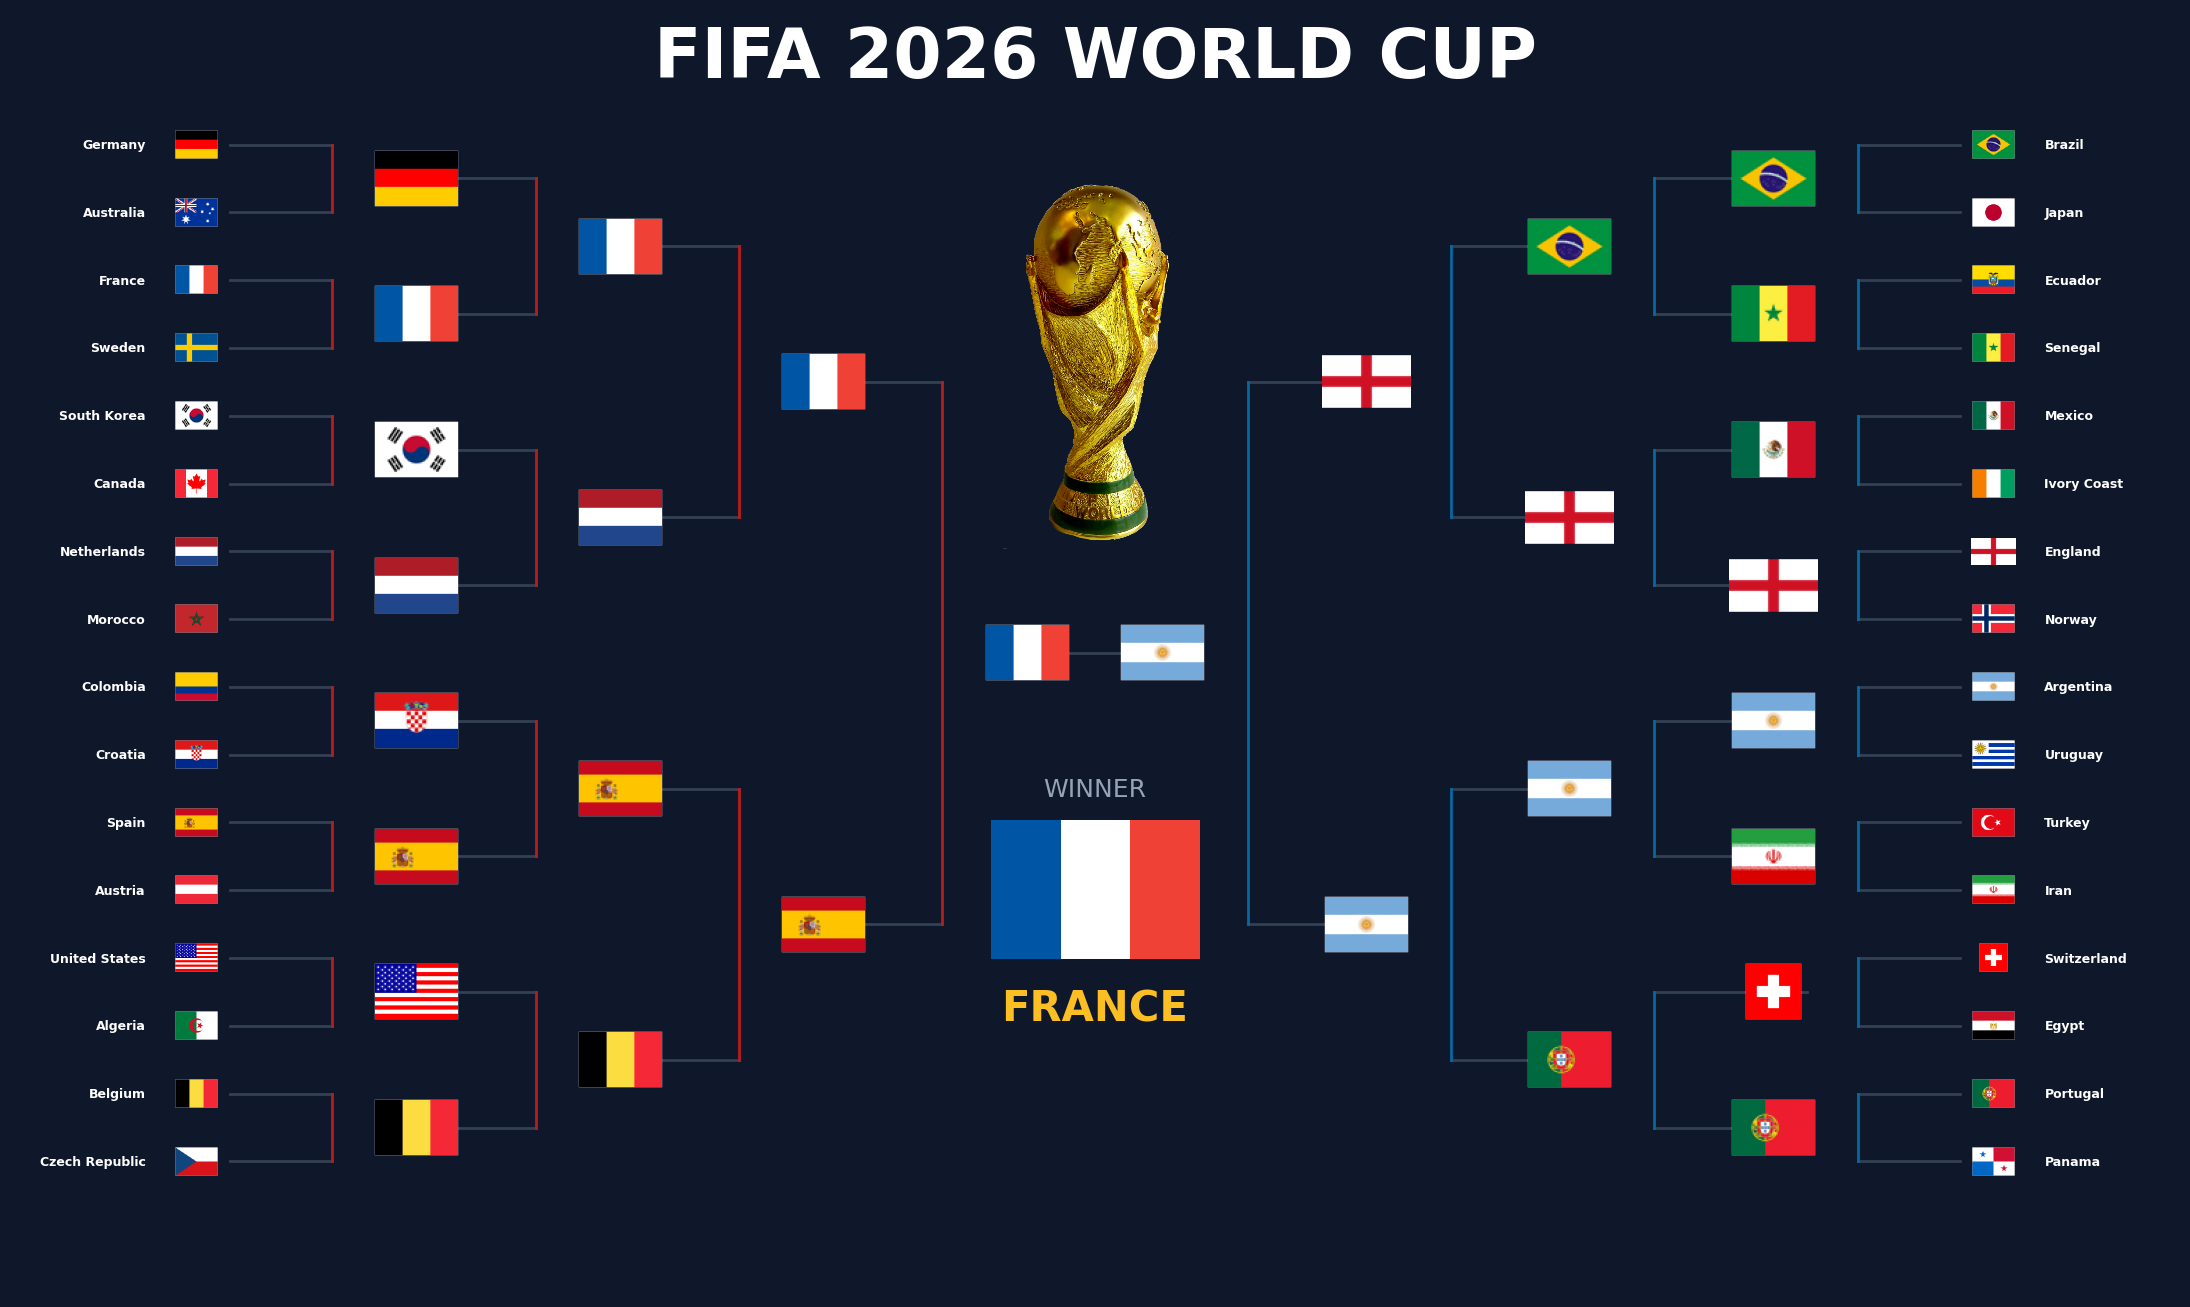

In [131]:
# We define our model
class RankIsEverything(Model):
    # Getting team rankings
    def feature_extractor(self, match: Match) -> tuple[dict, dict]:
        return ({'team_ranking': reference.rankings.loc[match.home.name, 'points'],
                 'opponent_ranking': reference.rankings.loc[match.away.name, 'points']},
                {'team_ranking': reference.rankings.loc[match.away.name, 'points'],
                 'opponent_ranking': reference.rankings.loc[match.home.name, 'points']})

    # Calculate higher ranking
    def xg_predictor(self, match_features: dict) -> float:
        home_points = match_features["team_ranking"]
        away_points = match_features["opponent_ranking"]
        # TODO
        if home_points > away_points:
            return 1
        else:
            return 0

    def goal_simulator(self, xg: float) -> int:
        return int(xg)

    def penalty_simulator(self, *args) -> str:
        return 'home'

    def feature_updater(self, match: Match):
        pass

# Create a tournament
t = Tournament(
    teams=reference.teams,
    gs_lb=reference.group_stage_leaderboard,
    matches=reference.matches
)
# Simulate with our model
t.simulate(RankIsEverything)
# Display the resulting bracket
t.display_bracket()

# One simulation isn't enough
## Monte-Carlo is the way to go
Gambling keeps coming up, maybe I should...

## We want to simulate thousands of tournaments
 - Result is a distribution, not a concrete outcome
   - Just because France might be favored in every matchup, doesn't mean they will win all of them
 - A team might be in a difficult group, but do well when they make knockout rounds

# Let's run a (small) simulation
For fun, let's make every game tottaly random

In [134]:
class TotallyRandom(Model):
    def feature_extractor(self, match: Match) -> tuple[dict, dict]:
        return ({}, {})

    # Pure random!
    def xg_predictor(self, match_features: dict) -> float:
        # TODO
        return 6 * random.random()

    def goal_simulator(self, xg: float) -> int:
        return int(xg)

    def penalty_simulator(self, *args) -> str:
        n = random.random()
        if n < 0.5:
            return 'home'
        else:
            return 'away'

    def feature_updater(self, match: Match):
        pass

# We will to 500 simulations with the random model
s = TournamentSimulator(
    num_simulations   = 500, # TODO
    model             = TotallyRandom,
    teams             = reference.teams,
    gs_lb             = reference.group_stage_leaderboard,
    matches           = reference.matches,
)
# Run the simulations
s.simulate()
# Display the results
s.summary

2026-05-27 15:34:41,658 ThreadPoolExecutor-19_0 starting
2026-05-27 15:34:41,677 ThreadPoolExecutor-19_0 tournament created


Simulating:   0%|          | 0/500 [00:00<?, ?it/s]

2026-05-27 15:34:41,780 ThreadPoolExecutor-19_0 simulation done
2026-05-27 15:34:41,795 ThreadPoolExecutor-19_0 starting
2026-05-27 15:34:41,800 ThreadPoolExecutor-19_0 tournament created


Simulating:   0%|          | 0/500 [00:00<?, ?it/s]

2026-05-27 15:34:41,891 ThreadPoolExecutor-19_0 simulation done
2026-05-27 15:34:41,907 ThreadPoolExecutor-19_0 starting
2026-05-27 15:34:41,911 ThreadPoolExecutor-19_0 tournament created


...

2026-05-27 15:35:11,218 ThreadPoolExecutor-19_0 simulation done
2026-05-27 15:35:11,228 ThreadPoolExecutor-19_0 starting
2026-05-27 15:35:11,231 ThreadPoolExecutor-19_0 tournament created


Simulating:   0%|          | 0/500 [00:00<?, ?it/s]

2026-05-27 15:35:11,274 ThreadPoolExecutor-19_0 simulation done


Aggregating:   0%|          | 0/500 [00:00<?, ?it/s]

,Win,Finals,Semi-Finals,Quarter-Finals,Round of 16,Round of 32
Japan,4.0,6.2,9.6,17.2,31.6,67.0
Norway,3.8,6.2,9.4,16.8,33.6,65.0
Bosnia and Herzegovina,3.2,4.2,9.4,17.2,34.8,68.0
Colombia,3.0,4.2,8.4,17.4,35.8,71.0
United States,3.0,4.6,9.0,19.0,35.2,67.8
Austria,3.0,4.4,8.4,15.0,30.6,68.0
Ecuador,3.0,4.4,8.8,16.4,33.8,65.8
Netherlands,2.8,4.6,8.8,17.0,35.8,67.4
Haiti,2.8,4.6,8.0,15.6,33.2,64.2
Canada,2.8,5.0,9.6,18.2,34.0,66.6


# So how will we actually simulate matches?

## Given two teams, how can we simulate many matches?

### Example: France vs Spain
If they play each other today, the outcome might be 1-0 \
If they then play tomorrow, the outcome might be 1-2 \
If they play again the next day, the outcome might be 3-3

## Key #1: Even between the same two teams with the same stats, outcomes should vary
This means there should be randomness \
Or maybe the unknown factor is the players' breakfasts, but we don't have that data, unfortunately

## Our randomness should follow some pattern

### Example: England vs American Samoa
Why American Samoa? 1) It's small 2) I'm craving girl scout cookies... \
We would predict England scoring a **lot**, and American Samoa hardly ever scoring \
There might be a world were England draws or even loses due to some supernatural events, but it would be *very* rare

## Key #2: The best we can do is xG (expected goals)
Maybe not *the* best, but close enough \
xG meassures how many goals we *expect* a team to score \
They may or may not score exactly that many goals, that's were our randomness comes it


# The Pipeline
```
 ______        _______        ____         _______
| Team | ---> | Stats | ---> | xG |  ---> | goals |
 ‾‾‾‾‾‾        ‾‾‾‾‾‾‾        ‾‾‾‾         ‾‾‾‾‾‾‾
```

## Teams
We start with two teams. What about them?

## We want stats `model.feature_extractor`
I scream, you scream, we all scream for betting!?
Well how else would we predict xG? Vibes? Jerseys?

## Put the stats to use `model.xg_predictor`
We use them to calculate xG
How? Regression!

## We sample `model.goal_simulator`
Giving us a concrete score

## What about OT? `model.penalty_simulator`
In case we need a winner

## Results


# Calculating stats
## Let's look at the data we'll be using
### `results.csv`
International soccer matches since 1872!


In [137]:
# kaggle is down
results = pd.read_csv("resources/data/results.csv")

## What's in `results`?

In [138]:
results

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False
...,...,...,...,...,...,...,...,...,...
49282,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49283,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49284,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49285,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True


## Let's filter out old games

In [9]:
results = results.dropna().reset_index(drop=True)
# Keeping only results from 1970 because modern
results = results[results['date'] > '1970-01-01'].reset_index(drop=True)

In [10]:
# we count every time a team has played at home and away
# home_games_played = results['home_team'].value_counts()
# away_games_played = results['away_team'].value_counts()

# we each teams' total games played by combining home and away games played
# games_played = pd.concat([home_games_played, away_games_played]).groupby(level=0).sum()

# now we add it back into the results
# results['home_team_games_played'] = results['home_team'].apply(lambda t: games_played[t])
# results['away_team_games_played'] = results['away_team'].apply(lambda t: games_played[t])

# keep only teams with 200 games played in past 45 years (5 games/year)
# and fricking Curaçao has only player 215 since 1970
# results = results[
    # (results['home_team_games_played'] > 200) &
    # (results['away_team_games_played'] > 20)
# ].reset_index(drop=True)

## Our first new stat: Importance
We want the World Cup to carry more importance than friendlies

In [139]:
# Categories
confedrational_tournaments = ['UEFA Euro', 'African Cup of Nations', 'AFC Asian Cup', 'CONCACAF Championship',
                              'Copa América', 'Gold Cup','Oceania Nations Cup', 'Confederations Cup']

qualifiers = ['AFC Asian Cup qualification', 'African Cup of Nations qualification',
                  'Gold Cup qualification', 'CONCACAF Championship qualification',
                  'Copa América qualification', 'FIFA World Cup qualification', 'Oceania Nations Cup qualification',
                  'UEFA Euro qualification']

nations_league = ['CONCACAF Nations League', 'CONCACAF Nations League qualification', 'UEFA Nations League']


tournament_categories = defaultdict(lambda: 'Friendlies/Low-Importance Competitions')

for t in confedrational_tournaments:
    tournament_categories[t] = 'Confederational Tournament'

for t in qualifiers:
    tournament_categories[t] = 'Nations League/Confederational Cup Qualifiers/WC Qualifiers'

for t in nations_league:
    tournament_categories[t] = 'Nations League/Confederational Cup Qualifiers/WC Qualifiers'

tournament_categories['FIFA World Cup'] = 'FIFA World Cup'

results['category'] = results.tournament.apply(lambda x: tournament_categories[x])

# Our (semi-arbitrary) importances
# Chose your own!
importances = {
    'FIFA World Cup': 1.0,
    'Confederational Tournament': 0.85,
    'Nations League/Confederational Cup Qualifiers/WC Qualifiers': 0.65,
    'Friendlies/Low-Importance Competitions': 0.5,
}

results['importance'] = results.category.apply(lambda x: importances[x])

# Let's get serious

## What stats will we use to predict xG?

### Elo Ranking
Like the official FIFA ranking, but calculated ourselfs
$$
R_{new} = R_{old} + \alpha i (W - W_e)
$$
 - $R$ is the rating/ranking whatever you want to call it
 - $\alpha$ is some scalar
 - $W$ is the actual outcome
 - $W_e$ is predicted ouctome based off the two teams rankings

### Attack Strength Indicator
Exactly what it sounds like
Measures a team's recent offense
$$
A_{new} = \mu g + (1−\mu)A_{old}
$$
 - $A$ is the attack strength indicator
 - $\mu$ is a factor based on the opposents defense indicator
 - $g$ is the number of goals scored by the team

### Defense Weakness Indicator
Exactly what it sounds like
Measures a team's recent defense
$$
D_{new} = \mu g + (1−\mu)D_{old}
$$
 - $A$ is the defense weakness indicator
 - $\mu$ is a factor based on the opposents attack indicator
 - $g$ is the number of goals conceded by the team

### Form
Created by yours truly
Measures a team's preformance in their last 5 games
$$
F = \sum^{5}_{k=1}{d_ki_kc_k}
$$
 - $F$ is the form
 - $d$ is the goal difference from a match
 - $i$ is the match importance
 - $c$ is difference of the teams rating (and completes my initials)


In [140]:
all_teams = list(
    set(results['home_team'].unique()) |
    set(results['away_team'].unique())
)
num_all_teams = len(all_teams)
ratings = {name: 0.0 for name in all_teams}
asi = {name: 0.0 for name in all_teams}
dwi = {name: 0.0 for name in all_teams}
form = {name: np.zeros(shape=(5, 3)) for name in all_teams}
results['home_rating'] = None
results['home_asi'] = None
results['home_dwi'] = None
results['home_form'] = None
results['away_rating'] = None
results['away_asi'] = None
results['away_form'] = None

matches_played = {name: 0 for name in all_teams}
teams_at_5_games_played = 0
all_teams_5_games_index = -1

def calculate_new_rating(match, t1=None, t2=None):
    team1 = match['home_team']
    team2 = match['away_team']

    # ratings
    if t1 is None:
        r1 = ratings[team1]
        r2 = ratings[team2]
    else:
        r1 = t1.rating
        r2 = t2.rating

    # scores
    g1 = match['home_score']
    g2 = match['away_score']

    # match result
    gd = g1 - g2
    W1 = 1 if gd > 0 else 0.5 if gd == 0 else 0
    W2 = 1 - W1

    # expected result
    d = r1 - r2
    try:
        We1 = 1 / (1 + 10**(-d))
    except:
        We1 = 0 if d < 0 else 1
    We2 = 1 - We1

    # some scalar
    a = 0.1
    # importance
    i = match['importance']

    r1 = r1 + a * i * (W1 - We1)
    r2 = r2 + a * i * (W2 - We2)

    # update the latest rating
    return r1, r2

def calculate_new_asi(match, t1=None, t2=None):
    team1 = match['home_team']
    team2 = match['away_team']

    if t1 is None:
        asi1 = asi[team1]
        asi2 = asi[team2]
        
        dwi1 = dwi[team1]
        dwi2 = dwi[team2]
    else:
        as1 = t1.asi
        as2 = t2.asi
        as1 = t1.dwi
        as2 = t2.dwi

    g1 = match['home_score']
    g2 = match['away_score']

    k = 2
    sig1 = 1 / (k ** (-dwi2) + 1)
    sig2 = 1 / (k ** (-dwi1) + 1)

    a = 0.25
    i = match['importance']
    u1 = a * i * (1.5 - sig1)
    u2 = a * i * (1.5 - sig2)

    asi1 = u1 * g1 + (1 - u1) * asi1
    asi2 = u2 * g2 + (1 - u2) * asi2

    return asi1, asi2

def calculate_new_dwi(match, t1=None, t2=None):
    team1 = match['home_team']
    team2 = match['away_team']

    if t1 is None:
        asi1 = asi[team1]
        asi2 = asi[team2]
        
        dwi1 = dwi[team1]
        dwi2 = dwi[team2]
    else:
        as1 = t1.asi
        as2 = t2.asi
        as1 = t1.dwi
        as2 = t2.dwi

    g1 = match['home_score']
    g2 = match['away_score']

    k = 2
    sig1 = 1 / (k ** (-asi2) + 1)
    sig2 = 1 / (k ** (-asi1) + 1)

    a = 0.25
    i = match['importance']
    u1 = a * i * (1.5 - sig1)
    u2 = a * i * (1.5 - sig2)

    dwi1 = u1 * g2 + (1 - u1) * dwi1
    dwi2 = u2 * g1 + (1 - u2) * dwi2

    return dwi1, dwi2

def calculate_new_form(match, t1=None, t2=None):
    team1 = match['home_team']
    team2 = match['away_team']

    if t1 is None:
        f1 = form[team1]
        f2 = form[team2]
    else:
        f1 = t1.form
        f2 = t2.form
    
    f1 = np.roll(f1, 3)
    f2 = np.roll(f2, 3)

    g1 = match['home_score']
    g2 = match['away_score']
    gd = g1 - g2

    r1 = match['home_rating']
    r2 = match['away_rating']

    rd1 = 1 / (math.exp(r2 - r1))
    rd2 = 1 / (math.exp(r1 - r2))

    i = match['importance']

    f1[0] = [ gd, i, rd1]
    f2[0] = [-gd, i, rd2]


    return f1, f2

def eval_form(f):
    return 0.1 * float(sum([gd * i * rd for gd, i, rd in f]))

def as_is(x):
    return x

for i, row in tqdm(results.iterrows(), total=results.shape[0], desc='Calculating ratings'):
    home = row['home_team']
    away = row['away_team']

    todos = [
        ("rating", calculate_new_rating, ratings, as_is),
        ("asi",    calculate_new_asi,    asi,     as_is),
        ("dwi",    calculate_new_dwi,    dwi,     as_is),
        ("form",   calculate_new_form,   form,    eval_form),
    ]
    for col_name, updater, table, evaluator in todos:
        # get the stat
        home_stat = table[home]
        away_stat = table[away]

        results.loc[i, 'home_'+col_name] = evaluator(home_stat)
        row['home_'+col_name] = evaluator(home_stat)
        results.loc[i, 'away_'+col_name] = evaluator(away_stat)
        row['away_'+col_name] = evaluator(away_stat)

        # update the stat
        home_stat, away_stat = updater(row)
        table[home] = home_stat
        table[away] = away_stat

    matches_played[home] += 1
    if (matches_played[home] == 5):
        teams_at_5_games_played += 1
    matches_played[away] += 1
    if (matches_played[away] == 5):
        teams_at_5_games_played += 1
    if teams_at_5_games_played == num_all_teams \
       and all_teams_5_games_index == -1:
        all_teams_5_games_index = i

# We add the stats to each team object
for team in reference.wc_teams:
    reference.teams[team].rating = ratings[team]
    reference.teams[team].asi = asi[team]
    reference.teams[team].dwi = dwi[team]
    reference.teams[team].form = form[team]

Calculating ratings:   0%|          | 0/49287 [00:00<?, ?it/s]

In [ ]:
# relevant_results = results[results.index > all_teams_5_games_index].reset_index(drop=True)
# relevant_results

# Now we create our dataset
## We'll train a machine-learning model on it
Regressors, but ML sounds cooler

In [157]:
entries = []
for i, row in tqdm(results.iterrows(), total=relevant_results.shape[0], desc='Creating training data'):
    date = row['date']
    team1 = row['home_team']
    team2 = row['away_team']
    team1_score = row['home_score']
    team2_score = row['away_score']
    r1 = row['home_rating']
    r2 = row['away_rating']
    asi1 = row['home_asi']
    asi2 = row['away_asi']
    dwi1 = row['home_dwi']
    dwi2 = row['away_dwi']
    f1 = row['home_form']
    f2 = row['away_form']
    i = row['importance']
    venue = 0 if row['neutral'] else int(team1 == row['country'])

    # trying predict how many goals team1 scored
    entries.append({
        'date': date,
        'team': team1,
        'opponent': team2,
        'team_rating': r1,
        'opponent_rating': r2,
        'team_asi': asi1,
        'opponent_dwi': dwi2,
        'team_form': f1,
        'opponent_form': f2,
        'importance': i,
        'venue': venue,
        'goals_scored': team1_score
    })

    # now for teaem2
    entries.append({
        'date': date,
        'team': team2,
        'opponent': team1,
        'team_rating': r2,
        'opponent_rating': r1,
        'team_asi': asi2,
        'opponent_dwi': dwi1,
        'team_form': f2,
        'opponent_form': f1,
        'importance': i,
        'venue': 1 - venue,
        'goals_scored': team2_score
    })

entries = pd.DataFrame(entries).dropna()

Creating training data:   0%|          | 0/37355 [00:00<?, ?it/s]

# We need some code to test our regressors, ignore it

In [158]:
def mean_log_likelihood(goals, lambdas):
    goals = np.asarray(goals)
    lambdas = np.asarray(lambdas)

    return poisson.logpmf(goals, lambdas).mean()
mll = mean_log_likelihood

def negative_expected_calibration_error(goals, lambdas, n_bins=10):
    goals = np.asarray(goals)
    lambdas = np.asarray(lambdas)

    order = np.argsort(lambdas)
    goals = goals[order]
    lambdas = lambdas[order]

    N = len(goals)
    bins = np.array_split(np.arange(N), n_bins)

    ece = 0.0

    for idx in bins:
        if len(idx) == 0:
            continue

        mean_goals = goals[idx].mean()
        mean_lambda = lambdas[idx].mean()

        ece += (len(idx) / N) * abs(mean_goals - mean_lambda)

    return -ece
nece = negative_expected_calibration_error

def negative_log_loss_1X2(goals, lambdas, eps=1e-15):
    scores = pairify(goals)
    lambdas_in_pairs = pairify(lambdas)
    losses = []

    for (g1, g2), (lam1, lam2) in zip(scores, lambdas_in_pairs):
        p_draw = skellam.pmf(0, lam1, lam2)
        p_home = 1 - skellam.cdf(0, lam1, lam2)
        p_away = skellam.cdf(-1, lam1, lam2)

        p_home = np.clip(p_home, eps, 1 - eps)
        p_draw = np.clip(p_draw, eps, 1 - eps)
        p_away = np.clip(p_away, eps, 1 - eps)

        # pick realized outcome
        if g1 > g2:
            p = p_home
        elif g1 == g2:
            p = p_draw
        else: # g1 < g2
            p = p_away

        losses.append(-np.log(p))

    return -np.mean(losses)
nll1x2 = negative_log_loss_1X2

def probability_integral_transform(goals, lambdas, random_state=42):
    goals = np.asarray(goals)
    lambdas = np.asarray(lambdas)

    rng = np.random.default_rng(random_state)

    u = rng.random(len(goals))

    pit = (
        poisson.cdf(goals - 1, lambdas)
        + u * poisson.pmf(goals, lambdas)
    )

    return pit
def plot_pit_histogram(pit_values, bins=10):
    plt.figure(figsize=(6, 4))
    plt.hist(pit_values, bins=bins, range=(0, 1), edgecolor="black")
    plt.xlabel("PIT value")
    plt.ylabel("Frequency")
    plt.title("PIT Histogram")
    plt.tight_layout()
    plt.show()
pit = probability_integral_transform

class ModelValidator:
    def __init__(self, xg_predictor_callable, data, goals, goal_generator_callable=None, fixed_lambdas=None, window_length=2000):
        self.build_xg_predictor = xg_predictor_callable
        self.data = data
        self.goals = goals
        self.build_goal_generator = goal_generator_callable
        self.fixed_lambdas = fixed_lambdas
        self.WINDOW_LENGTH = window_length
        self.summary = {}

    def get_summary(self):
        return self.summary.copy()

    def evaluate_xg_predictor(self, goals, lambdas):
        return {
            'mll': mll(goals, lambdas),
            'nece': nece(goals, lambdas),
            'nll1x2': nll1x2(goals, lambdas),
            'pit': pit(goals, lambdas)
        }

    def plot_xg_predictor_summary(self):
        summary = self.summary

        mlls = summary.get('mlls', [])
        nll1x2 = summary.get('nll1x2', [])
        neces = summary.get('neces', [])
        train_times = summary.get('training-times', [])
        infer_times = summary.get('inference-times', [])
        pits = summary.get('pits', [])

        n = len(mlls)
        x = np.arange(1, n + 1)

        fig = plt.figure(figsize=(18, 16))
        fig.suptitle("xG Predictor Validation Summary", fontsize=18)

        gs = fig.add_gridspec(
            nrows=4,
            ncols=6,
            height_ratios=[1, 1, 1, 1.1]
        )

        ax_mll = fig.add_subplot(gs[0, 1:5])
        ax_mll.plot(x, mlls, marker='o')
        ax_mll.set_title("Mean Log-Likelihood (MLL)")
        ax_mll.set_xlabel("Window")
        ax_mll.grid(True)

        ax_nll1x2 = fig.add_subplot(gs[1, 0:3])
        ax_nll1x2.plot(x, nll1x2, marker='o')
        ax_nll1x2.set_title("Negative Log-Loss (1X2)")
        ax_nll1x2.set_xlabel("Window")
        ax_nll1x2.grid(True)

        ax_nece = fig.add_subplot(gs[1, 3:6])
        ax_nece.plot(x, neces, marker='o')
        ax_nece.set_title("Negative ECE (NECE)")
        ax_nece.set_xlabel("Window")
        ax_nece.grid(True)

        ax_train = fig.add_subplot(gs[2, 0:3])
        ax_train.plot(x, train_times, marker='o')
        ax_train.set_title("Training Time")
        ax_train.set_xlabel("Window")
        ax_train.set_ylabel("Seconds")
        ax_train.grid(True)

        ax_infer = fig.add_subplot(gs[2, 3:6])
        ax_infer.plot(x, infer_times, marker='o')
        ax_infer.set_title("Inference Time")
        ax_infer.set_xlabel("Window")
        ax_infer.set_ylabel("Seconds")
        ax_infer.grid(True)

        if pits:
            n_pits = len(pits)

            idxs = [
                0,
                n_pits // 4,
                n_pits // 2,
                (3 * n_pits) // 4,
                n_pits - 1
            ]

            titles = [
                "First window",
                "End of 1st quarter",
                "Middle",
                "Start of final quarter",
                "Last window"
            ]

            for i, (idx, title) in enumerate(zip(idxs, titles)):
                ax = fig.add_subplot(gs[3, i])
                ax.hist(pits[idx], bins=10, range=(0, 1), edgecolor='black')
                ax.set_title(title)
                ax.set_xlabel("PIT")
                ax.grid(True)

            fig.axes[-5].set_ylabel("Count")

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    def validate(self):
        data = self.data
        goals = self.goals
        N = len(data)
        n_windows = N // self.WINDOW_LENGTH + 1
        summary = self.summary

        summary['training-times'], summary['inference-times'] = [], []

        if self.build_goal_generator is None:
            summary['mlls'], summary['neces'], summary['nll1x2'], summary['pits'] = [], [], [], []

        else:
            summary['gg-training-times'], summary['gg-inference-times'] = [], []
            summary['hits'], summary['1X2'], summary['nmse'], summary['gambler'], summary['nw2d'] = [], [], [], [], []
            summary['scores-analysis'], summary['preds-analysis'] = [], []


        for i in range(n_windows - 1):
            # print(f'\n({i + 1})')
            train_data = data[: (i + 1) * self.WINDOW_LENGTH]
            train_goals = goals[: (i + 1) * self.WINDOW_LENGTH]

            test_data = data[(i + 1) * self.WINDOW_LENGTH: min(N, (i + 2) * self.WINDOW_LENGTH)]
            test_goals = goals[(i + 1) * self.WINDOW_LENGTH: min(N, (i + 2) * self.WINDOW_LENGTH)]

            xg_predictor = self.build_xg_predictor()

            before = time()
            xg_predictor.fit(train_data, train_goals)
            summary['training-times'].append(time() - before)
            # print(f"xG Predictor training time: {summary['training-times'][-1]:.4f}")

            before = time()
            lambdas = xg_predictor.predict(test_data)
            summary['inference-times'].append(time() - before)
            # print(f"xG Predictor inference time: {summary['inference-times'][-1]:.4f}")

            if self.build_goal_generator is None:
                # goal generator is not provided
                # we will only evaluate xg predictor
                eval_dict = self.evaluate_xg_predictor(test_goals, lambdas)
                summary['mlls'].append(eval_dict['mll'])
                summary['neces'].append(eval_dict['nece'])
                summary['nll1x2'].append(eval_dict['nll1x2'])
                summary['pits'].append(eval_dict['pit'])
                # print(f"xG Predictor Mean Log Likelihood: {summary['mlls'][-1]:.4f}")
                # print(f"xG Predictor Negative Log-Loss 1X2: {summary['nll1x2'][-1]:.4f}")
                # print(f"xG Predictor Negative Expected Calibration Error: {summary['neces'][-1]:.4f}")
            else:
                pass

def plot_model_comparison(summaries):
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle("xG Predictor Model Comparison", fontsize=18)

    gs = fig.add_gridspec(
        nrows=3,
        ncols=6,
        height_ratios=[1, 1, 1]
    )

    # ---------- Row 1: MLL (centered) ----------
    ax_mll = fig.add_subplot(gs[0, 1:5])
    for model_name, summary in summaries.items():
        values = summary.get("mlls", [])
        if not values:
            continue
        x = np.arange(1, len(values) + 1)
        ax_mll.plot(x, values, marker='o', label=model_name)

    ax_mll.set_title("Mean Log-Likelihood (MLL)")
    ax_mll.set_xlabel("Window")
    ax_mll.grid(True)
    ax_mll.legend()

    # ---------- Row 2: NLL 1X2 + NECE ----------
    ax_nll1x2 = fig.add_subplot(gs[1, 0:3])
    for model_name, summary in summaries.items():
        values = summary.get("nll1x2", [])
        if not values:
            continue
        x = np.arange(1, len(values) + 1)
        ax_nll1x2.plot(x, values, marker='o', label=model_name)

    ax_nll1x2.set_title("Negative Log-Loss (1X2)")
    ax_nll1x2.set_xlabel("Window")
    ax_nll1x2.grid(True)
    ax_nll1x2.legend()

    ax_nece = fig.add_subplot(gs[1, 3:6])
    for model_name, summary in summaries.items():
        values = summary.get("neces", [])
        if not values:
            continue
        x = np.arange(1, len(values) + 1)
        ax_nece.plot(x, values, marker='o', label=model_name)

    ax_nece.set_title("Negative ECE (NECE)")
    ax_nece.set_xlabel("Window")
    ax_nece.grid(True)
    ax_nece.legend()

    # ---------- Row 3: Times ----------
    ax_train = fig.add_subplot(gs[2, 0:3])
    for model_name, summary in summaries.items():
        values = summary.get("training-times", [])
        if not values:
            continue
        x = np.arange(1, len(values) + 1)
        ax_train.plot(x, values, marker='o', label=model_name)

    ax_train.set_title("Training Time (s)")
    ax_train.set_xlabel("Window")
    ax_train.set_ylabel("Seconds")
    ax_train.grid(True)
    ax_train.legend()

    ax_infer = fig.add_subplot(gs[2, 3:6])
    for model_name, summary in summaries.items():
        values = summary.get("inference-times", [])
        if not values:
            continue
        x = np.arange(1, len(values) + 1)
        ax_infer.plot(x, values, marker='o', label=model_name)

    ax_infer.set_title("Inference Time (s)")
    ax_infer.set_xlabel("Window")
    ax_infer.set_ylabel("Seconds")
    ax_infer.grid(True)
    ax_infer.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def analyze_pxgbr(data, goals, dates, window_length=2000):
    N = len(data)
    n_windows = N // window_length + 1

    lambdas = [None] * window_length
    importances = []
    for i in tqdm(range(n_windows - 1)):
        train_data = data[: (i + 1) * window_length]
        train_goals = goals[: (i + 1) * window_length]

        test_data = data[(i + 1) * window_length: min(N, (i + 2) * window_length)]
        test_goals = goals[(i + 1) * window_length: min(N, (i + 2) * window_length)]
        first_date = dates[(i + 1) * window_length]

        # print(f'Window ({i + 1}) - {first_date}')
        
        pxgbr = PoissonXGBR()
        pxgbr.fit(train_data, train_goals)
        test_lambdas = pxgbr.predict(test_data)
        lambdas.extend(test_lambdas)

        test_scores = pairify(test_goals)
        test_lambdas_in_pairs = pairify(test_lambdas)

        imp_dict = {c: imp for c, imp in zip(train_data.columns, pxgbr.feature_importances_)}

        importances.append(imp_dict)

    return lambdas, importances

def plot_feature_importance_trends(names, feature_dicts, eatures):
    # Build a list of values per feature
    feature_values = {f: [] for f in features}
    for fd in feature_dicts:
        for f in features:
            feature_values[f].append(fd.get(f, 0))  # default 0 if missing

    # Plot
    plt.figure(figsize=(10, 6))
    markers = ['o', 's', '^', 'v', 'D', 'x', "1", "*"]  # one marker per feature
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray']

    for f, m, c in zip(features, markers, colors):
        plt.plot(names, feature_values[f], marker=m, linestyle='-', color=c, label=f)

    plt.xlabel("Window / Tournament")
    plt.ylabel("Feature Importance")
    plt.title("Feature Importances Over Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Our regressor models to predict xG
Maher model says
$$
log(\lambda) = A - D + H
$$
 - $A$ is attack strength indicator
 - $D$ is defesnse weakness indicator
 - $H$ is home field advantage

Our regression models generally do
$$
log(\lambda) = \sum^{n}_{k=0}{W_if_i}
$$
 - $W$ is the unkown weight
 - $f$ is the stat/feature
and the outputs fit a poisson distribution (soon)

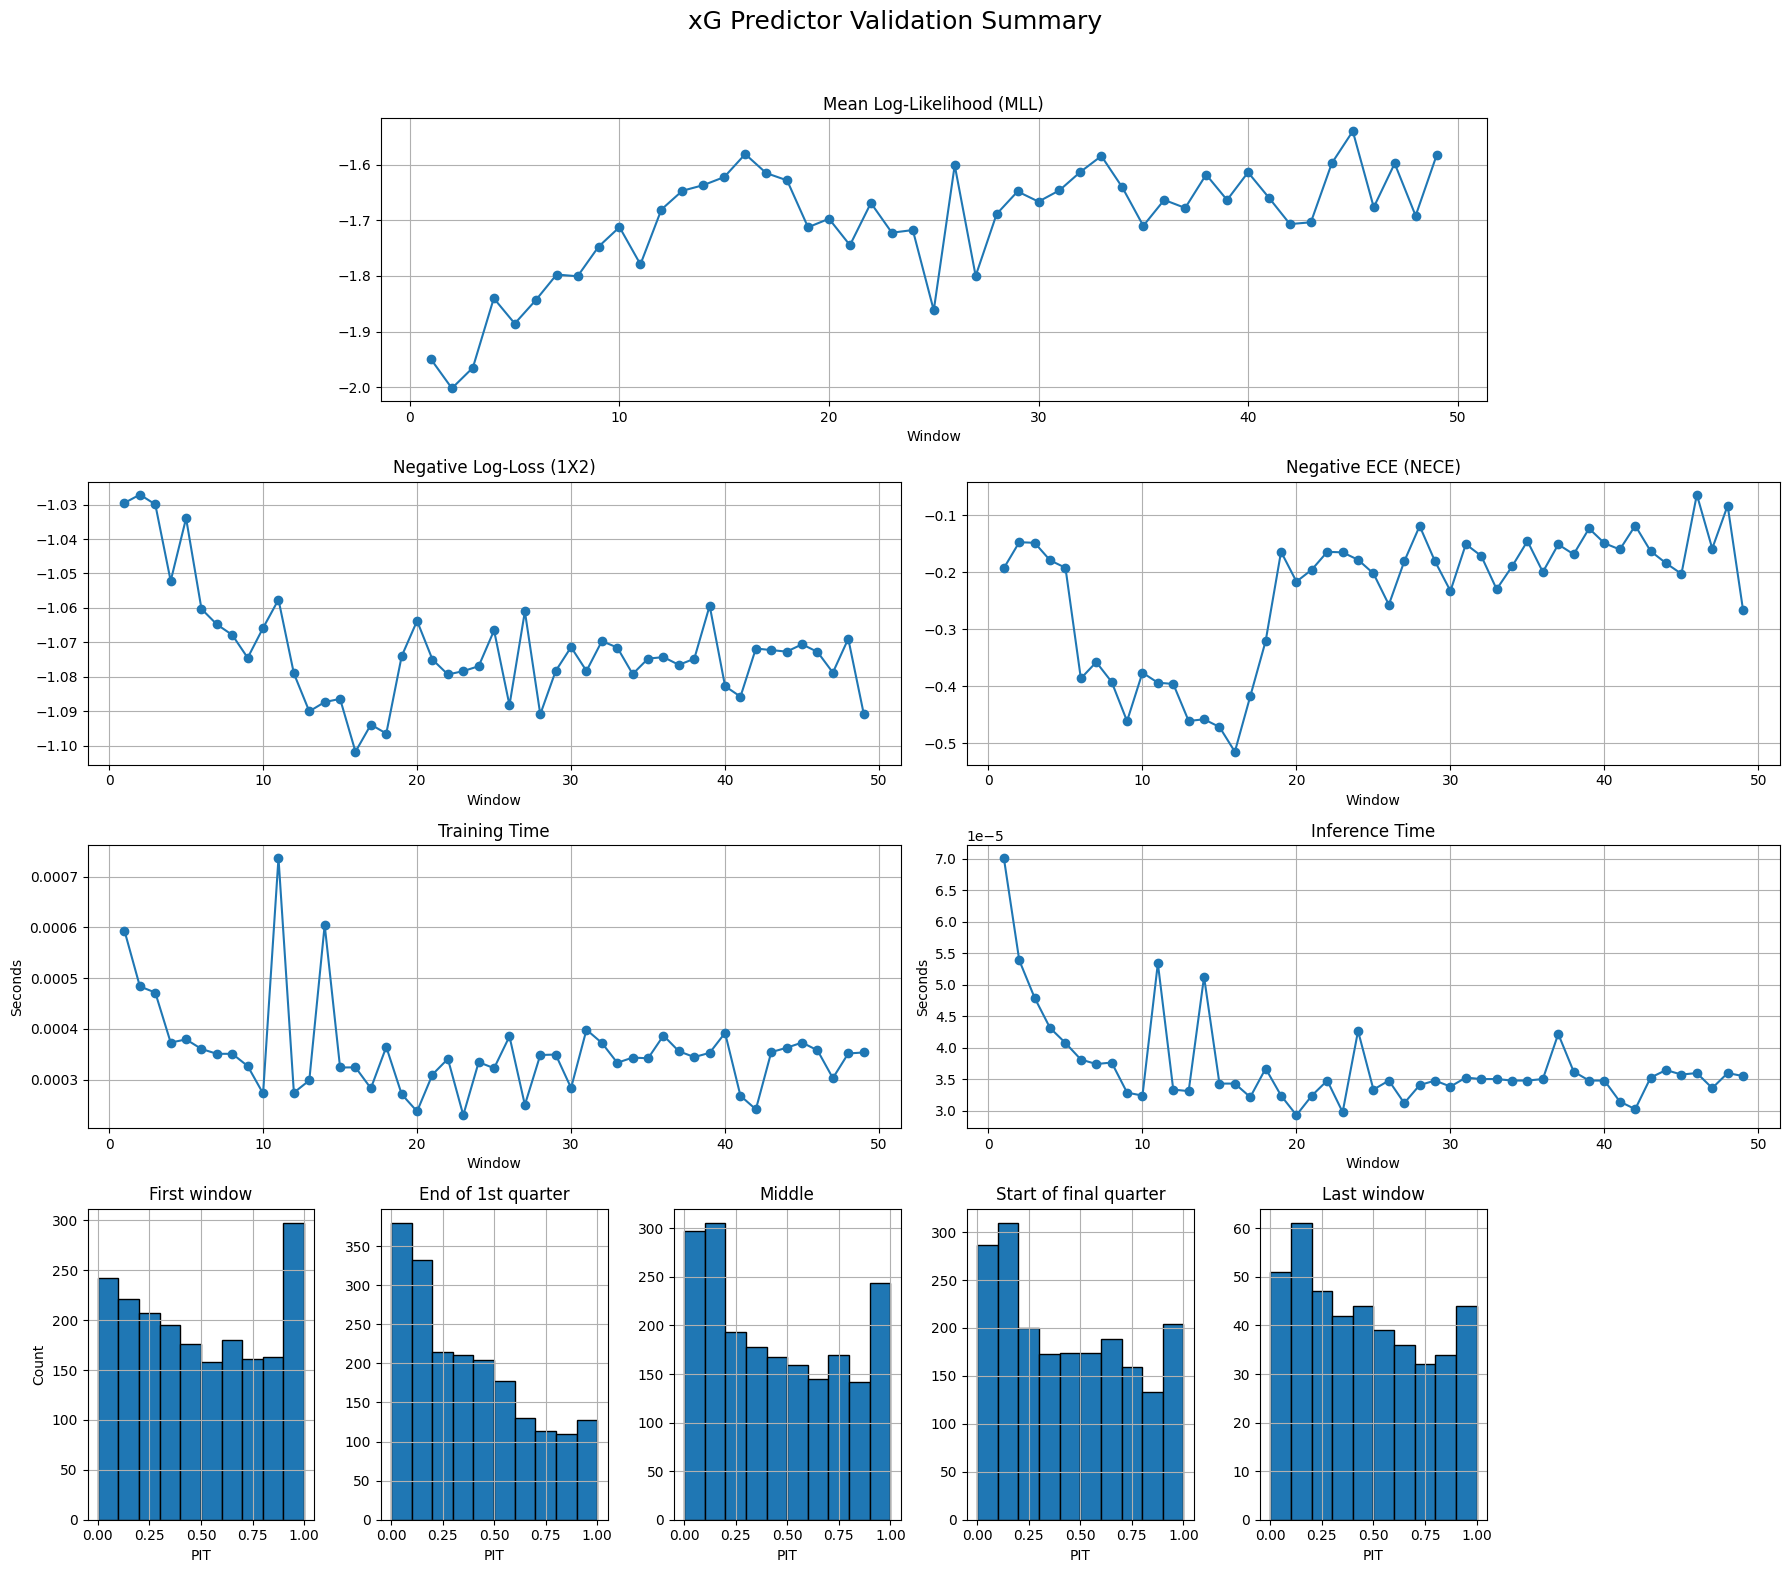

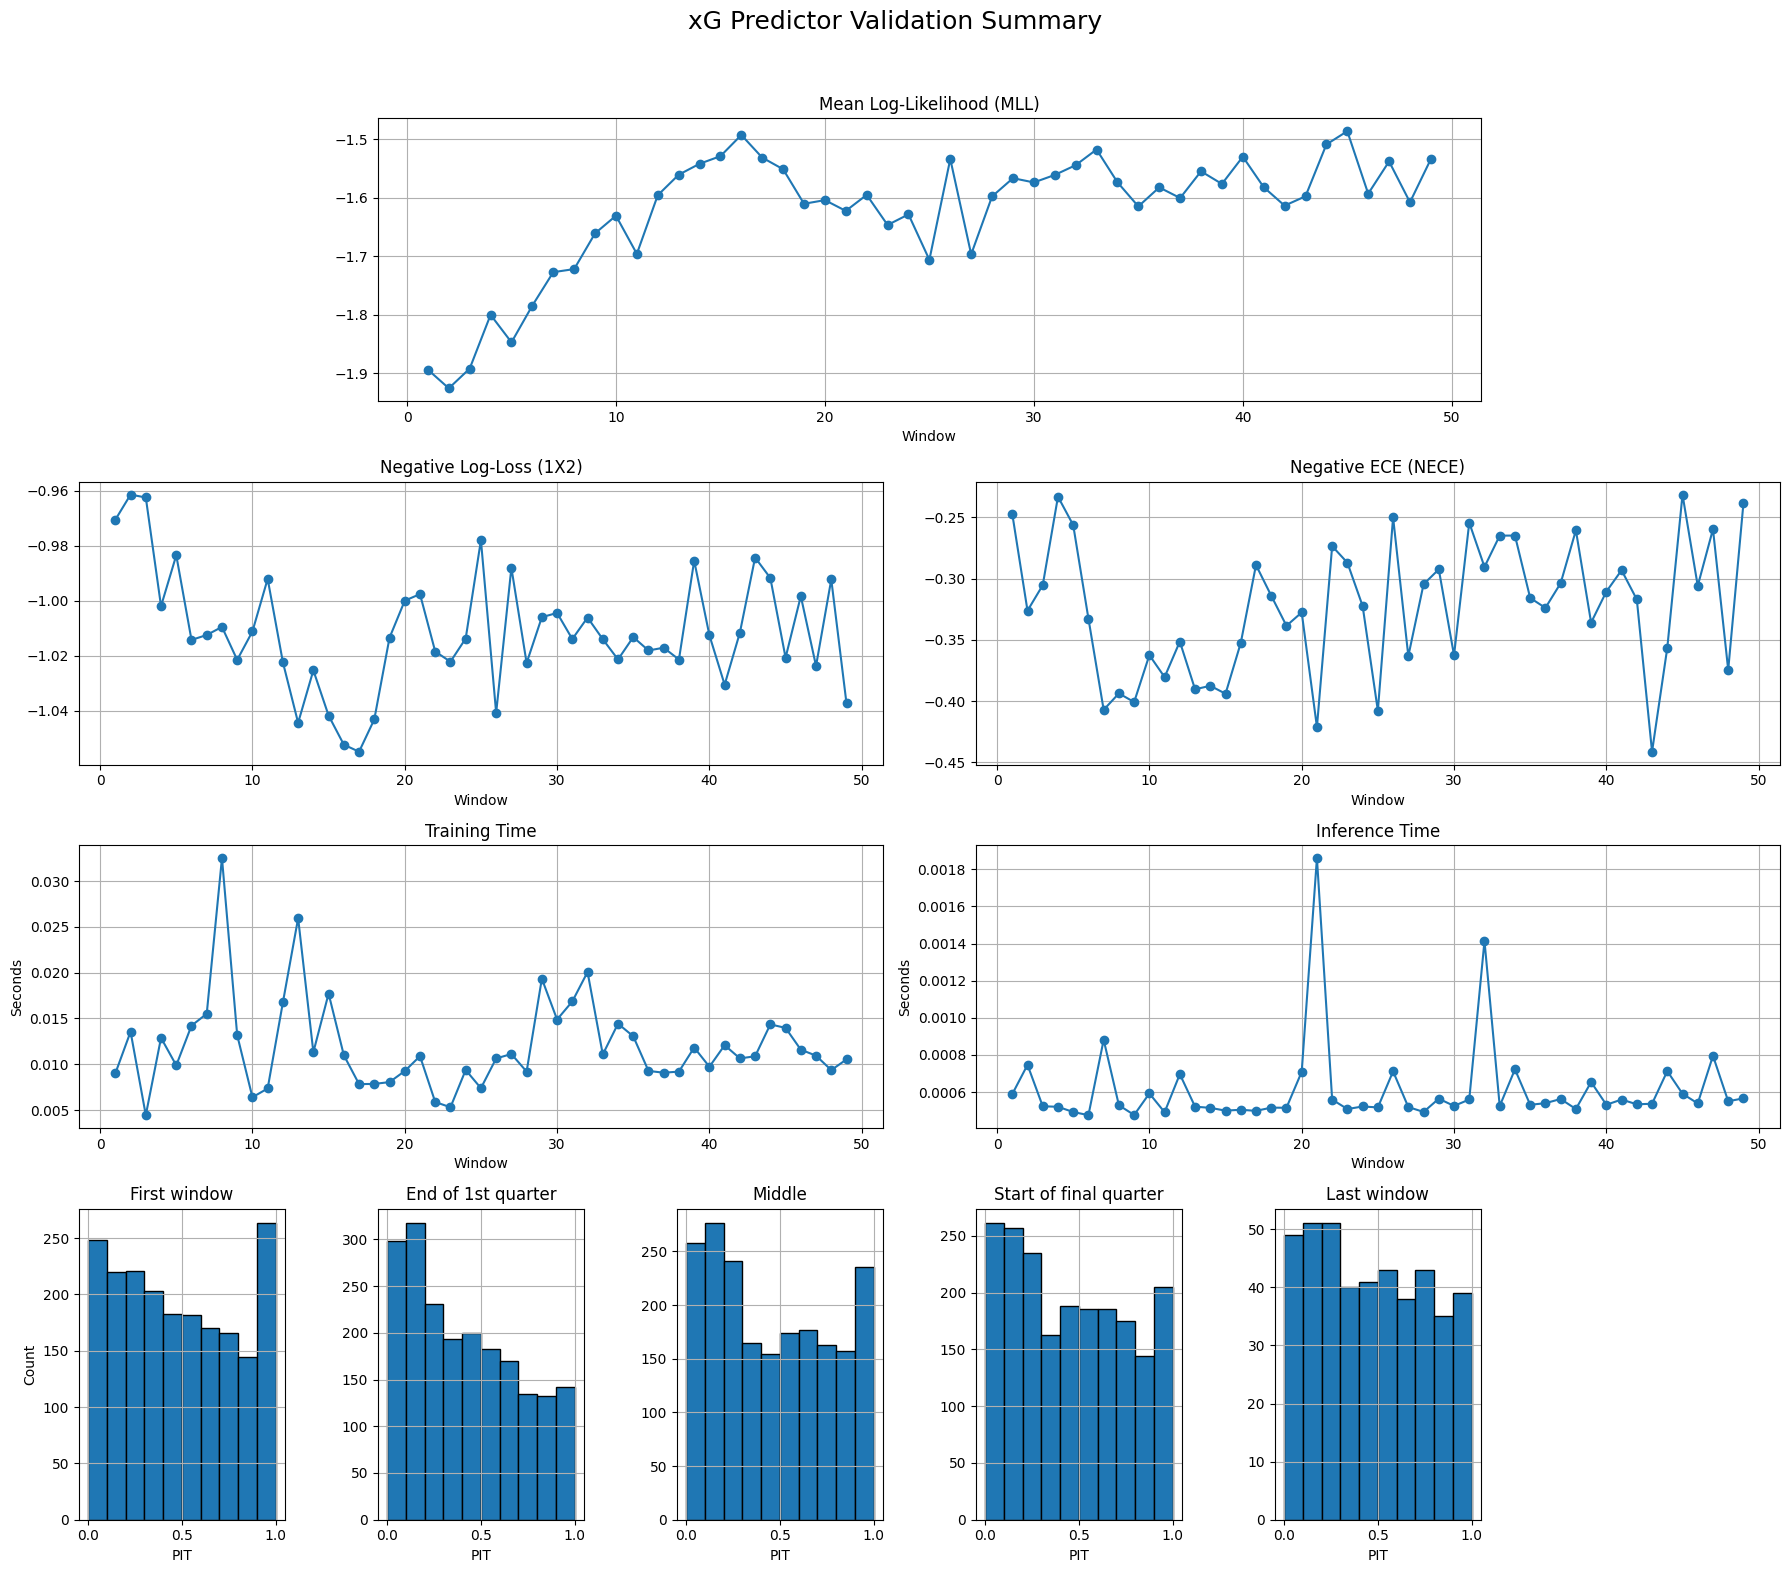

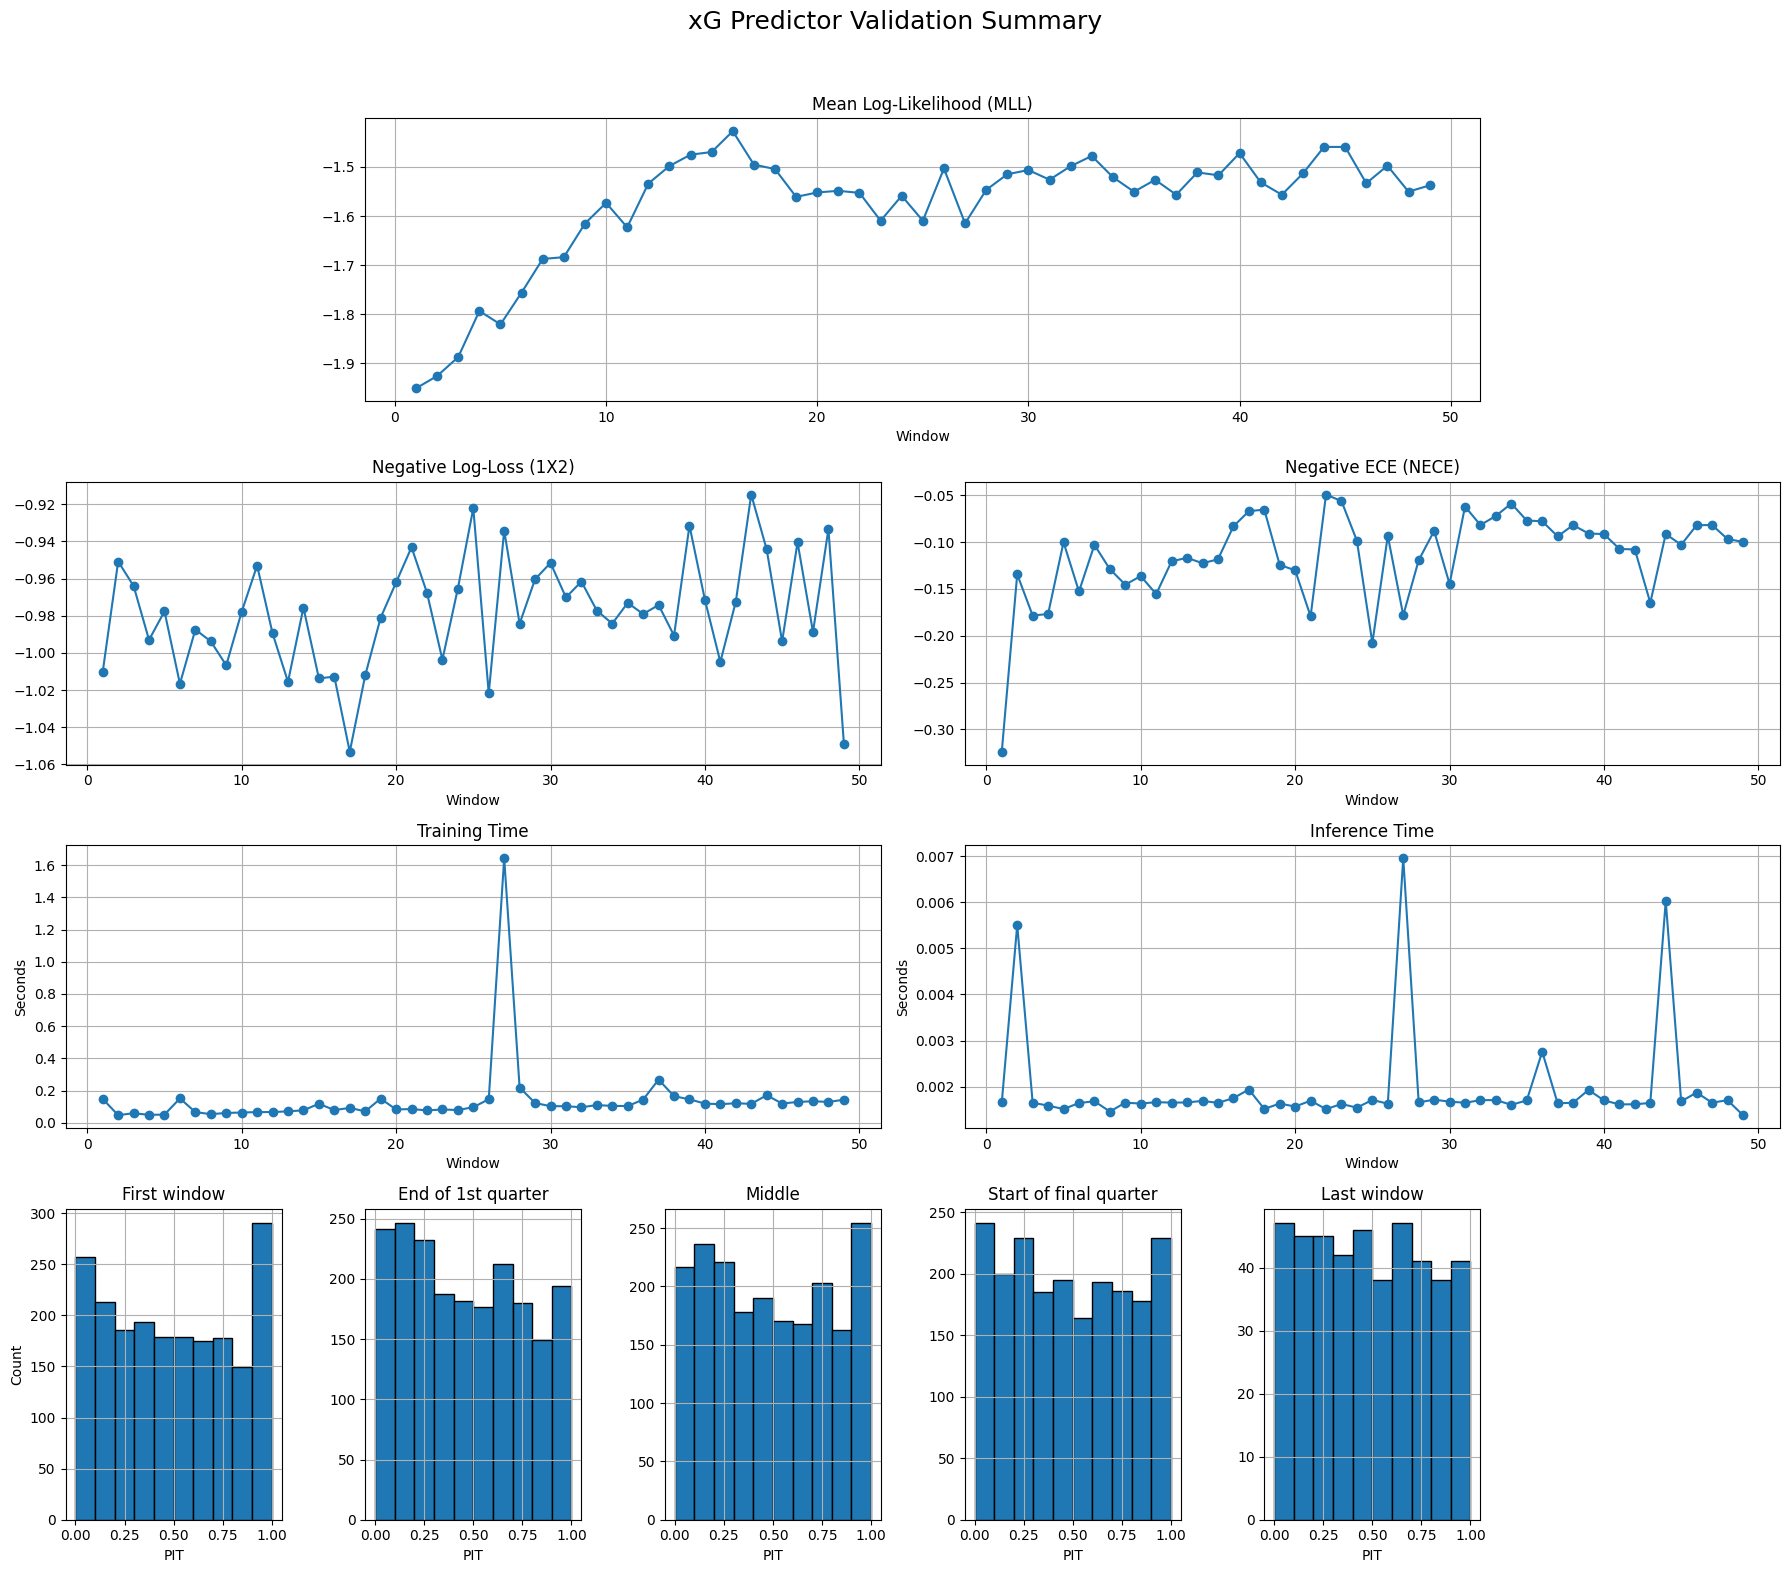

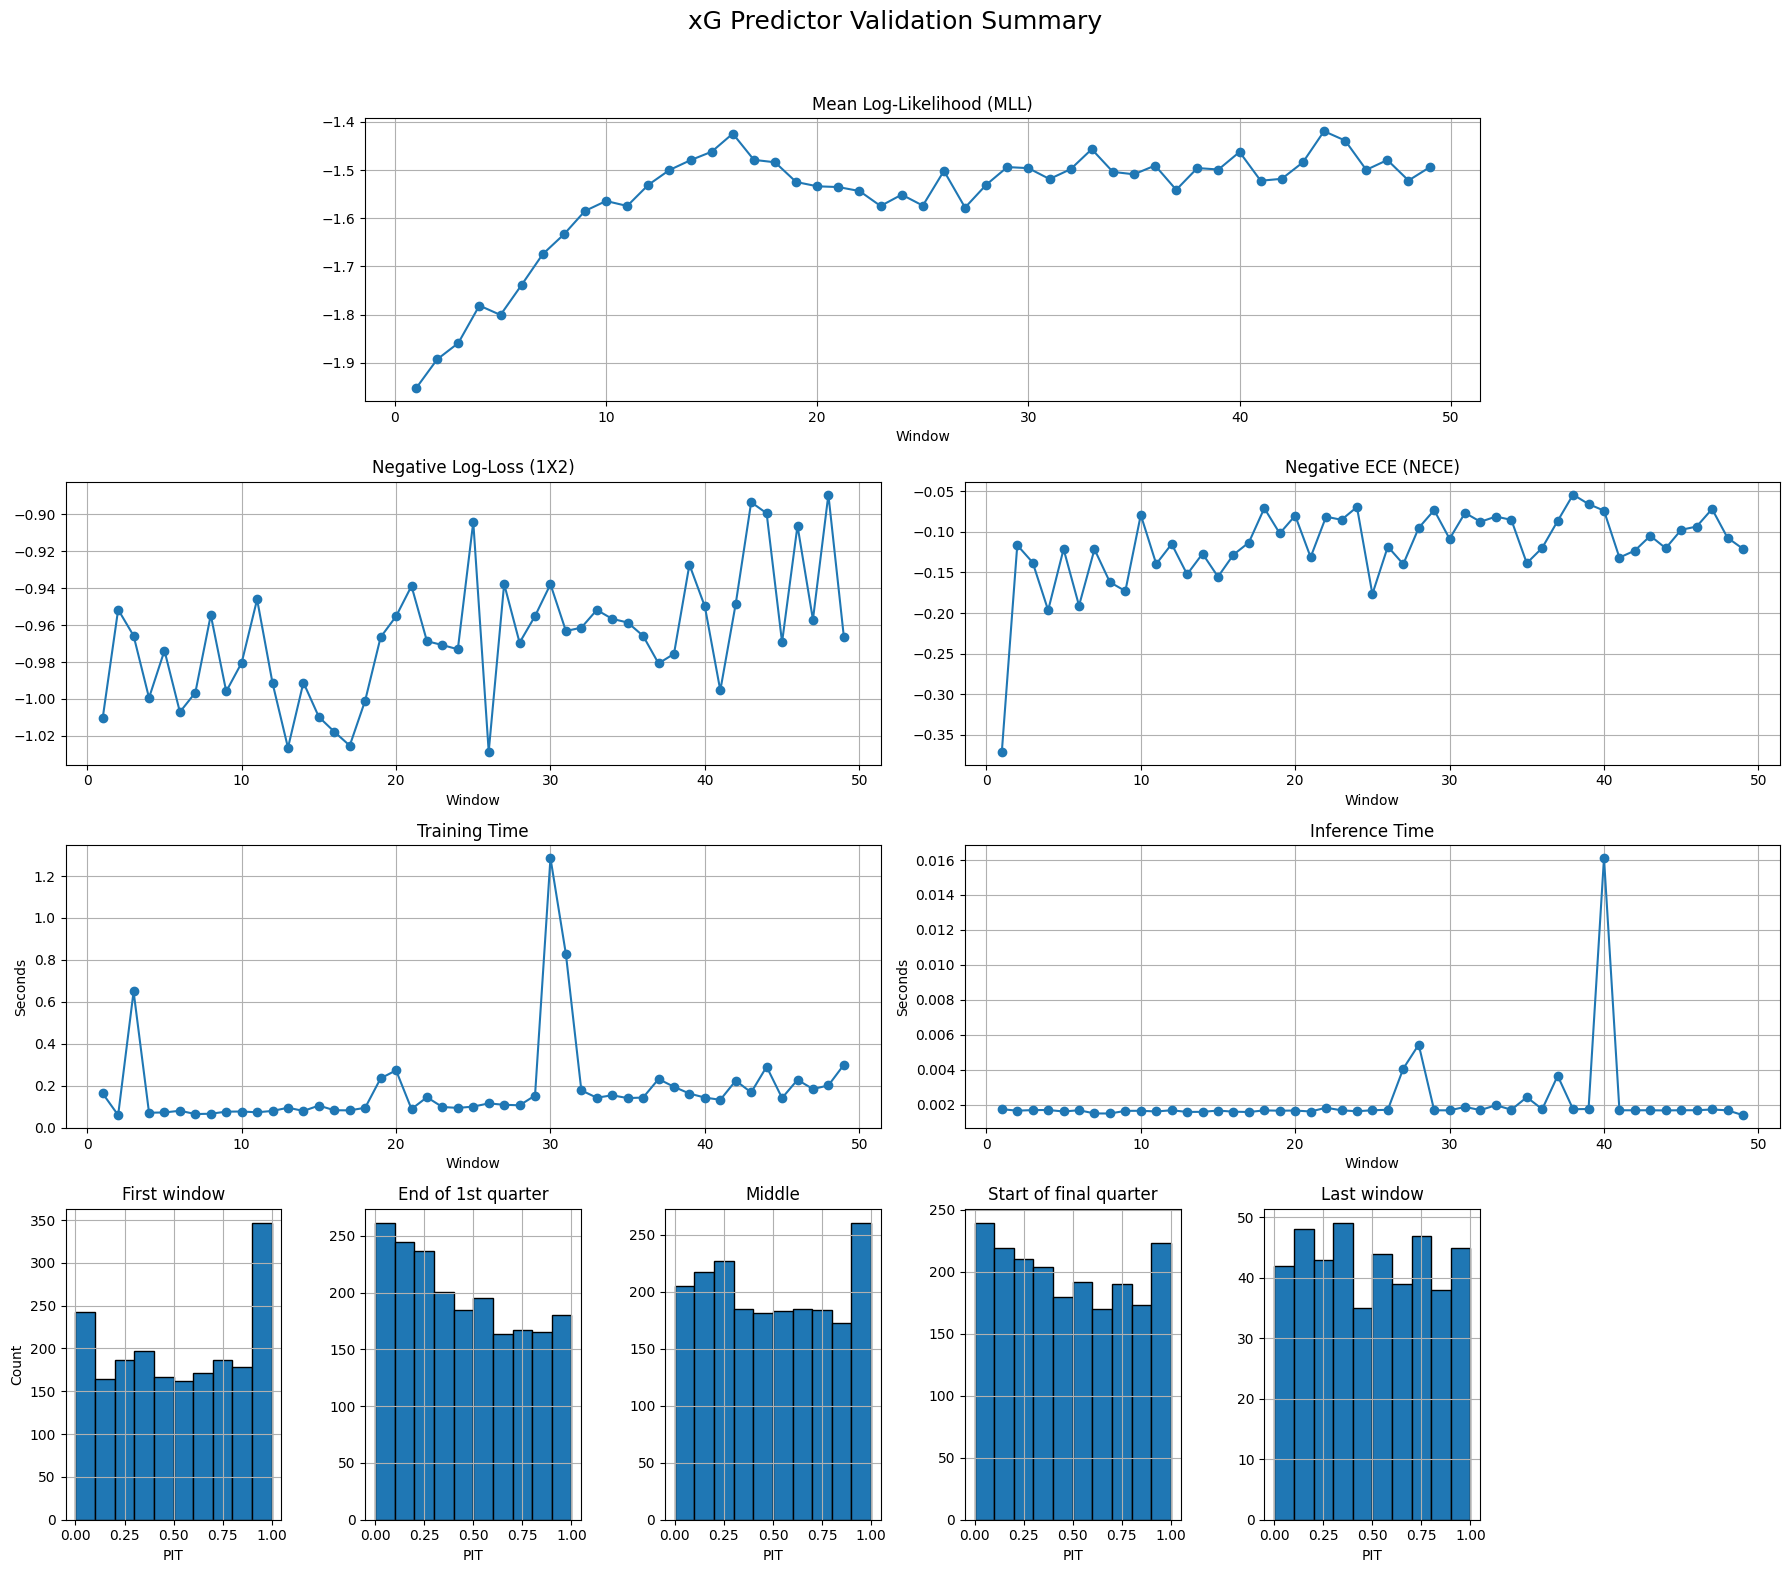

In [165]:
maher_features = ['team_asi', 'opponent_dwi', 'venue']
most_features = ['team_rating', 'team_asi', 'opponent_dwi', 'importance']#, 'venue']
all_features = ['team_rating', 'team_asi', 'opponent_dwi', 'team_form', 'opponent_form', 'importance']#, 'venue']

summaries = Object()

validator = ModelValidator(DummyRegressor, entries[all_features], entries['goals_scored'])
validator.validate()
summaries['Dummy Regressor'] = validator.get_summary()
validator.plot_xg_predictor_summary()

validator = ModelValidator(PoissonRegressor, entries[maher_features], entries['goals_scored'])
validator.validate()
summaries['Maher Model'] = validator.get_summary()
validator.plot_xg_predictor_summary()

PoissonXGBR = lambda: XGBRegressor(objective='count:poisson', eval_metric='poisson-nloglik',
                                   n_estimators=100, learning_rate=0.1)
validator = ModelValidator(PoissonXGBR, entries[maher_features], entries['goals_scored'])
validator.validate()
summaries["PXGBR Maher"] = validator.get_summary()
validator.plot_xg_predictor_summary()

PoissonXGBR = lambda: XGBRegressor(objective='count:poisson', eval_metric='poisson-nloglik',
                                   n_estimators=100, learning_rate=0.1)
validator = ModelValidator(PoissonXGBR, entries[all_features], entries['goals_scored'])
validator.validate()
summaries["PXGBR All"] = validator.get_summary()
validator.plot_xg_predictor_summary()

plot_model_comparison(summaries)

# What features matter?
according to our model, don't quote me

  0%|          | 0/49 [00:00<?, ?it/s]

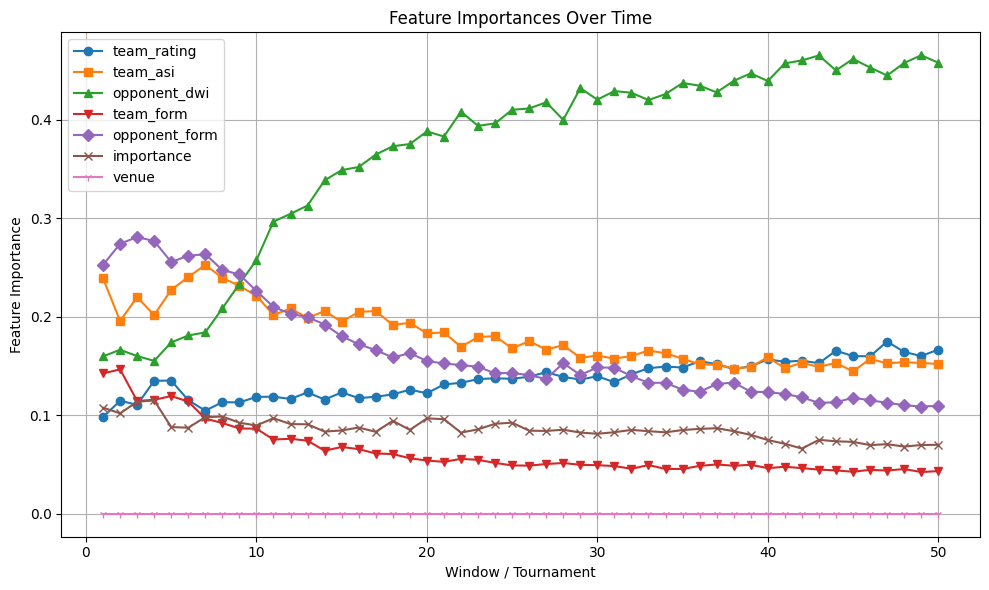

In [169]:
xgs, importances = analyze_pxgbr(entries[all_features], entries['goals_scored'], entries['date'])

entries['xg'] = xgs
model = PoissonXGBR()
used_features = all_features
model.fit(entries[used_features], entries['goals_scored'])
model.predict(entries[used_features])
d = {c: i for c, i in zip(used_features, model.feature_importances_)}
plot_feature_importance_trends(range(1,len(importances) + 2), importances + [d], used_features)

# The poisson distribution
It's not venem!

## What is does
It's a distribution showing how many goals are expected to be scored, given an average amount of goals scored
 - avg home goals = 1.79
 - avg away goals = 1.11

## We want to sample it
Thankfully, the math is alreay tucked away in a library!
We use this to simulate goals score from xG

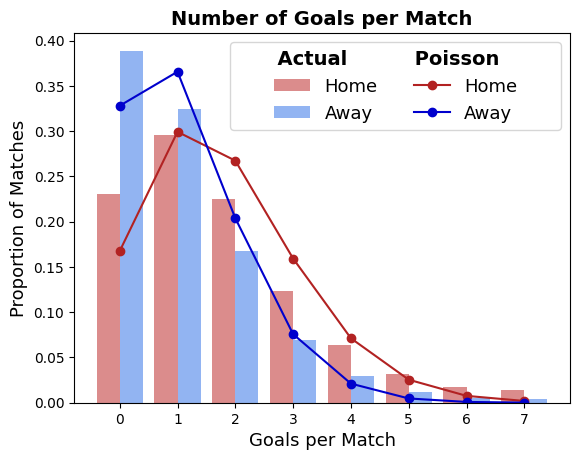

In [170]:
ha = results.copy()
ha = ha[ha['neutral'] == False]
ha = ha[['home_score', 'away_score']]

# plot the acutally data
plt.hist(ha.values, bins=range(9), alpha=0.7, label=['Home', 'Away'], density=True, color=["indianred", "cornflowerblue"])

# plot the poisson prediction based the probability mass function
poisson_pred = np.column_stack([[poisson.pmf(i, ha.mean()[j]) for i in range(8)] for j in ha.mean().index])
plt.plot([i-0.5 for i in range(1,9)], poisson_pred[:,0],
                  linestyle='-', marker='o',label="Home", color = 'firebrick')
plt.plot([i-0.5 for i in range(1,9)], poisson_pred[:,1],
                  linestyle='-', marker='o',label="Away", color = 'mediumblue')

# fancify the plot
legend = plt.legend(loc='upper right', fontsize=13, ncol=2)
legend.set_title("      Actual          Poisson        ", prop = {'size':'14', 'weight':'bold'})
plt.xticks([i-0.5 for i in range(1, 9)],[i for i in range(8)])
plt.xlabel("Goals per Match",size=13)
plt.ylabel("Proportion of Matches",size=13)
plt.title("Number of Goals per Match",size=14,fontweight='bold')
plt.show()

# Putting it all together
Please tell my simulation has finished

In [173]:
class XGBR_Poisson(Model):
    pxgbr = None
    features = ['team_rating', 'team_asi', 'opponent_dwi', 'importance', 'team_form', 'opponent_form']
    def __init__(self):
        self.xg_model = deepcopy(XGBR_Poisson.pxgbr)

    def feature_extractor(self, match: Match) -> tuple[dict, dict]:
        home_reatures = {
            'team_rating': match.home.rating,
            'team_asi': match.home.asi,
            'opponent_dwi': match.away.dwi,
            'importance': 1,
            'team_form': eval_form(match.home.form),
            'opponent_form': eval_form(match.away.form),
            # 'venue': 0.5, # not taking into account usa,mex,can
        }

        away_reatures = {
            'team_rating': match.away.rating,
            'team_asi': match.away.asi,
            'opponent_dwi': match.home.dwi,
            'importance': 1,
            'team_form': eval_form(match.away.form),
            'opponent_form': eval_form(match.home.form),
#            'venue': 0.5, # not taking into account usa,mex,can
        }

        return home_reatures, away_reatures

    def xg_predictor(self, match_features: dict) -> float:
        return self.xg_model.predict(pd.DataFrame([match_features]))[0]

    def goal_simulator(self, xg: float) -> int:
        # random sample from poisson distribution
        return random.poisson(xg)
        # return int(xg)

    def penalty_simulator(self, *args) -> str:
        # penalties are random enough already
        n = random.random()
        if n < 0.5:
            return 'home'
        else:
            return 'away'

    def feature_updater(self, match: Match):
        match_df = pd.DataFrame([{
            'home_team': match.home.name,
            'away_team': match.away.name,
            'away_rating': match.away.rating,
            'home_rating': match.home.rating,
            'away_asi': match.away.asi,
            'home_asi': match.home.asi,
            'away_dwi': match.away.dwi,
            'home_dwi': match.home.dwi,
            'away_form': match.away.form,
            'home_form': match.home.form,
            'importance': 1,
        }])
        match.home.rating, match.away.rating = calculate_new_rating(match_df, match.home, match.away)
        match.home.asi, match.away.asi = calculate_new_asi(match_df, match.home, match.away)
        match.home.dwi, match.away.dwi = calculate_new_dwi(match_df, match.home, match.away)
        match.home.form, match.away.form = calculate_new_form(match_df, match.home, match.away)
        ratings

start = timer()
XGBR_Poisson.pxgbr = PoissonXGBR()
XGBR_Poisson.pxgbr.fit(entries[XGBR_Poisson.features], entries['goals_scored'])
end = timer()
print(end - start)

1.4162612540021655


In [ ]:
start = timer()
s = TournamentSimulator(
    num_simulations   = 300,
    teams             = reference.teams,
    gs_lb             = reference.group_stage_leaderboard,
    matches           = reference.matches,
    model             = XGBR_Poisson,
    # max_workers=12
)
s.simulate()
end = timer()
print("TIME: ", end - start)
display(s.summary)
display(s.avg_gs_lb)
# 1000 -> 548s ~ 9min

2026-05-27 17:00:59,621 ThreadPoolExecutor-20_0 starting
2026-05-27 17:00:59,635 ThreadPoolExecutor-20_0 tournament created


Simulating:   0%|          | 0/300 [00:00<?, ?it/s]

2026-05-27 17:01:00,431 ThreadPoolExecutor-20_0 simulation done
2026-05-27 17:01:00,437 ThreadPoolExecutor-20_0 starting
2026-05-27 17:01:00,445 ThreadPoolExecutor-20_0 tournament created


Simulating:   0%|          | 0/300 [00:00<?, ?it/s]

2026-05-27 17:01:01,013 ThreadPoolExecutor-20_0 simulation done
2026-05-27 17:01:01,023 ThreadPoolExecutor-20_0 starting
2026-05-27 17:01:01,026 ThreadPoolExecutor-20_0 tournament created


...

Simulating:   0%|          | 0/300 [00:00<?, ?it/s]

2026-05-27 17:03:04,704 ThreadPoolExecutor-20_0 simulation done
2026-05-27 17:03:04,706 ThreadPoolExecutor-20_0 starting
2026-05-27 17:03:04,712 ThreadPoolExecutor-20_0 tournament created


Simulating:   0%|          | 0/300 [00:00<?, ?it/s]

2026-05-27 17:03:05,262 ThreadPoolExecutor-20_0 simulation done
2026-05-27 17:03:05,265 ThreadPoolExecutor-20_0 starting
2026-05-27 17:03:05,271 ThreadPoolExecutor-20_0 tournament created


Simulating:   0%|          | 0/300 [00:00<?, ?it/s]

In [86]:
s.summary.sort_index()

,Win,Finals,Semi-Finals,Quarter-Finals,Round of 16,Round of 32
Algeria,1.7,3.8,7.7,17.1,31.4,65.4
Argentina,3.6,7.5,16.1,27.3,45.7,77.2
Australia,0.3,1.9,4.9,12.6,32.0,70.4
Austria,3.8,7.4,13.5,25.0,46.2,82.7
Belgium,11.8,18.8,27.8,45.8,66.6,92.9
Bosnia and Herzegovina,0.5,1.2,4.8,11.6,33.4,71.9
Brazil,0.9,2.9,7.6,17.0,31.2,78.8
Canada,0.4,1.3,4.6,11.4,31.1,70.6
Cape Verde,0.4,0.6,2.4,8.2,23.3,64.3
Colombia,1.4,3.1,8.2,14.6,33.1,66.0


In [98]:
preds = reference.analyst_predicitons.copy()
difference = s.summary.sort_index() - preds.sort_index()
difference.sort_values(by='Win', key=abs, ascending=False)

,Win,Finals,Semi-Finals,Quarter-Finals,Round of 16,Round of 32
Belgium,9.39,13.12,14.94,16.49,11.96,3.08
Netherlands,8.52,13.29,19.43,23.26,23.40,7.22
France,-7.20,-10.61,-13.96,-16.49,-16.34,-6.69
England,-6.92,-9.18,-11.13,-11.32,-9.56,-4.88
Argentina,-6.66,-10.45,-14.18,-18.07,-17.41,-19.48
Brazil,-5.83,-9.64,-14.25,-21.11,-30.58,-18.22
Spain,-5.08,-7.44,-11.46,-9.89,-9.67,-2.97
Germany,4.93,8.58,11.29,13.64,6.60,-1.41
Portugal,3.72,5.23,5.27,4.94,0.28,-2.16
Austria,3.29,5.84,9.11,14.34,21.39,15.29


In [99]:
error = difference / preds.sort_index()
error.sort_values(by='Win', key=abs, ascending=False)

,Win,Finals,Semi-Finals,Quarter-Finals,Round of 16,Round of 32
Cape Verde,19.000000,3.000000,2.750000,2.106061,1.527115,0.913121
Czech Republic,10.428571,4.647059,2.717472,1.206186,0.640099,0.281970
Austria,6.450980,3.743590,2.075171,1.345216,0.862152,0.226821
Algeria,5.538462,3.750000,1.873134,1.428977,0.688172,0.148577
Iraq,4.555556,3.827586,2.777778,1.876254,1.660654,1.215613
Uzbekistan,4.000000,2.571429,2.679245,1.605263,0.810700,0.309927
Belgium,3.896266,2.309859,1.161742,0.562607,0.218887,0.034291
DR Congo,3.444444,1.564103,1.500000,1.122642,0.622035,0.249709
Panama,3.285714,2.658537,2.285714,1.104019,0.774562,0.452626
Jordan,3.000000,2.333333,1.380952,1.139037,0.755319,0.098393
